This notebook is intended to be the one where I gather the results for the GETLM.

In [1]:
# We start by importing all the necessary packages
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
import torch
from tqdm import tqdm
import math
from Python_files import time_integration_functions as TST
from Python_files import TLM_Test as TT
from Python_files import ETLM as ETLMC
from Python_files import LETLM_ensemble as LETLMC
from Python_files import IETLM_ensemble as IETLMC
from Python_files import GETLM as GETLMC


#  We also need to set the precision to be higher as we are working with very small perturbations
torch.set_default_dtype(torch.float64)


In [2]:
# # I will also be defining a L2 norm function
# def L2_norm(result, reality):
#     L2 = sum(abs(result - reality))/sum(abs(reality))
#     return L2

def L2_norm(result, reality):
    # Using PyTorch's built-in L2 norm (p=2)
    L2 = torch.norm(result - reality, p=2) / torch.norm(reality, p=2)
    return L2

In [3]:
# We will start by looking at Crank-Nicolson
# The first step is to the parameters for out model

N = 40 # The number of grid points
dx = 1 # The spacing
F_L96 = 8 # The Lorenz 96 forcing term
dt = 0.1 # This gives a time step of six hours
timesteps =  14400 # This moves the model forward ten years
alpha = 1 # set for no reason
beta = 1 # set for no reason
model_parameters = (N, dx, dt, alpha, beta, F_L96)
model = TST.CN_L96
x_values = np.arange(1, N+1)  
spin_up_time = 1000

In [4]:
# we start by initialising the model with a vector of random normal noise
x_in = torch.randn(N,1)
# We then run the model so that the Lorenz 96 model has reached it's 'equilibrium'
for i in tqdm(range(spin_up_time-1)):
    x_in = TST.run_model(x_in, model, model_parameters)

x_out = TST.run_model(x_in, model, model_parameters)

100%|██████████| 999/999 [00:00<00:00, 11379.67it/s]


In [5]:
# Now that the model is spun up, we need to generate the ensembles

# The first step to do this is to work out what we want to use as our stencil
stencil_members_future_CN = [-2,-1,0,1]
stencil_members_current_CN = [-2,-1,0,1]
stencil_members_past_CN = [0]
stencil_members_large_CN = [stencil_members_future_CN, stencil_members_current_CN, stencil_members_past_CN]

# Now that we have our stencil we can calculate how many ensemble members we need 
ensemble_size_CN = 5 + len(stencil_members_future_CN) + len(stencil_members_current_CN) + len(stencil_members_past_CN)

# We now need to set the size of the perturbation that we will use for generating the ensemble TLMS
SD_pert = 10**(-7)

# We also need to define our test perturbation
Test_pert_current = torch.randn(N) * SD_pert
Test_pert_past = torch.randn(N) * SD_pert
Test_pert = (Test_pert_current, Test_pert_past)


test_final_pert, Ensemble_final, Ensembles, test_guess, unpert_run=  GETLMC.GETLM_ensemble_generator_mult(x_out, ensemble_size_CN, SD_pert, model, model_parameters, Test_pert, number_of_steps = 10)


In [6]:
IETLM_STENCIL_LARGE = [[-2,-1,0,1],[-2,-1,0,1]]
LETLM_STENCIL_LARGE = [[0],[-3,-2,-1,0,1,2,3]]


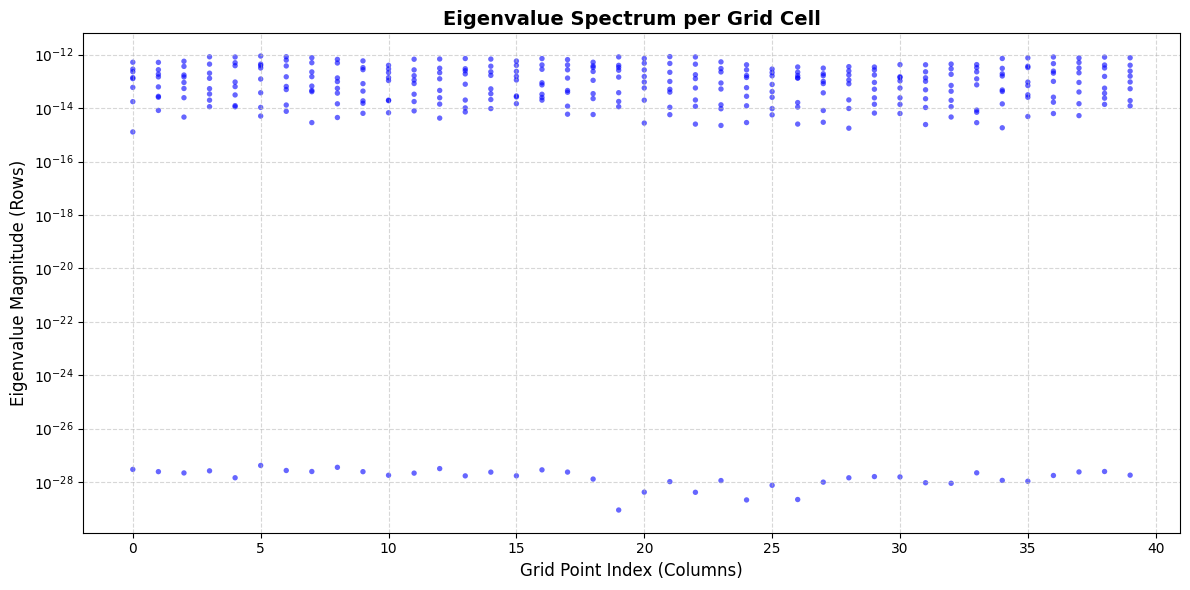

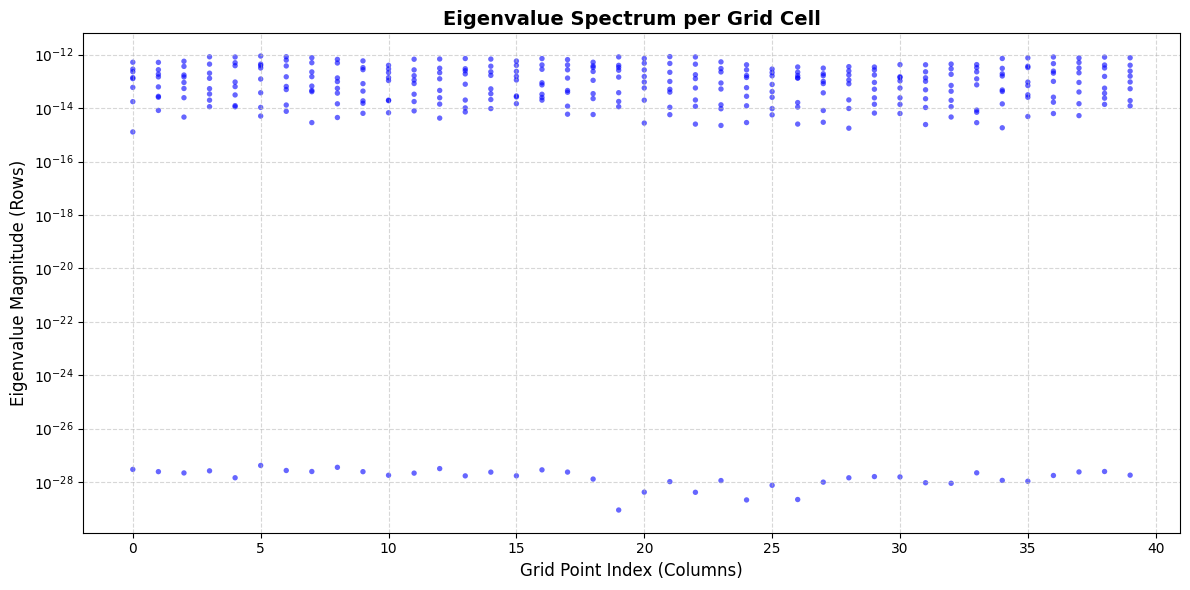

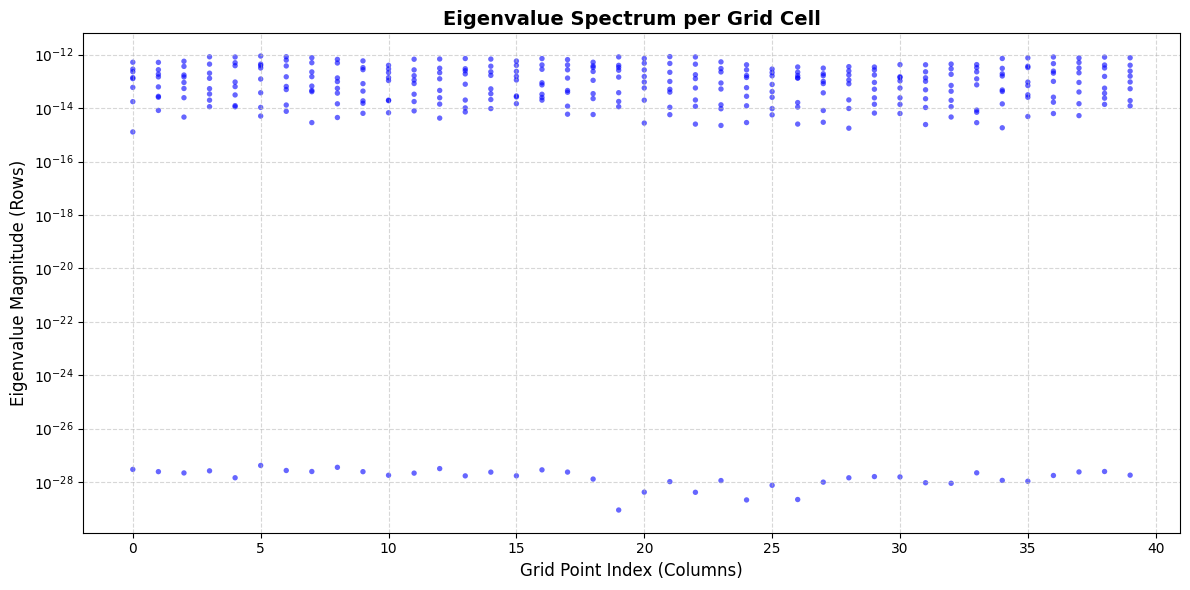

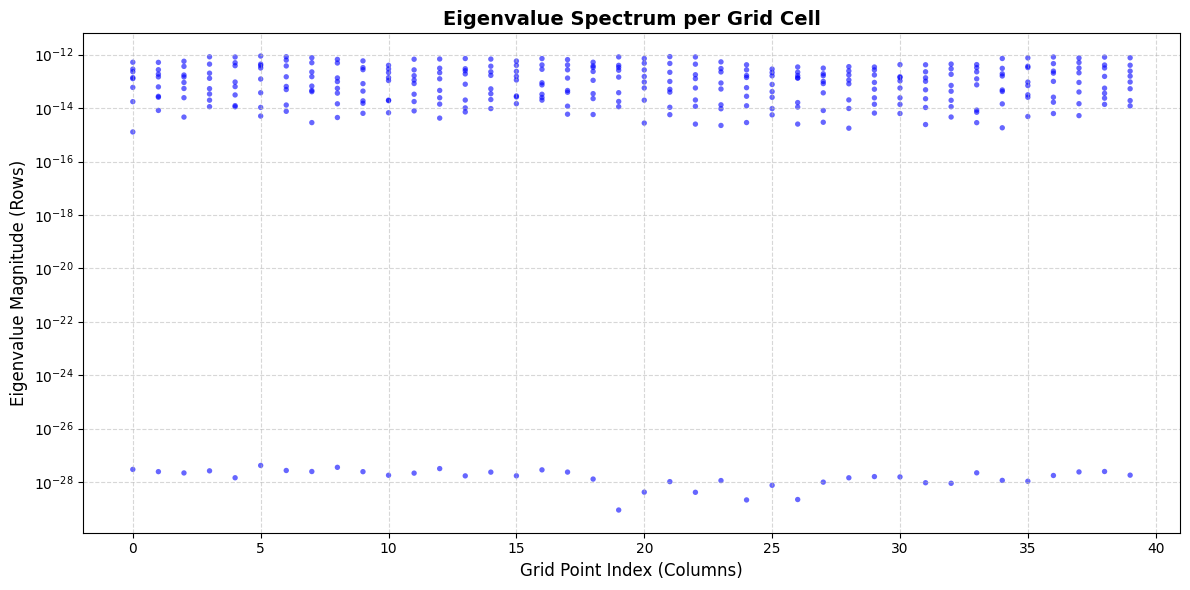

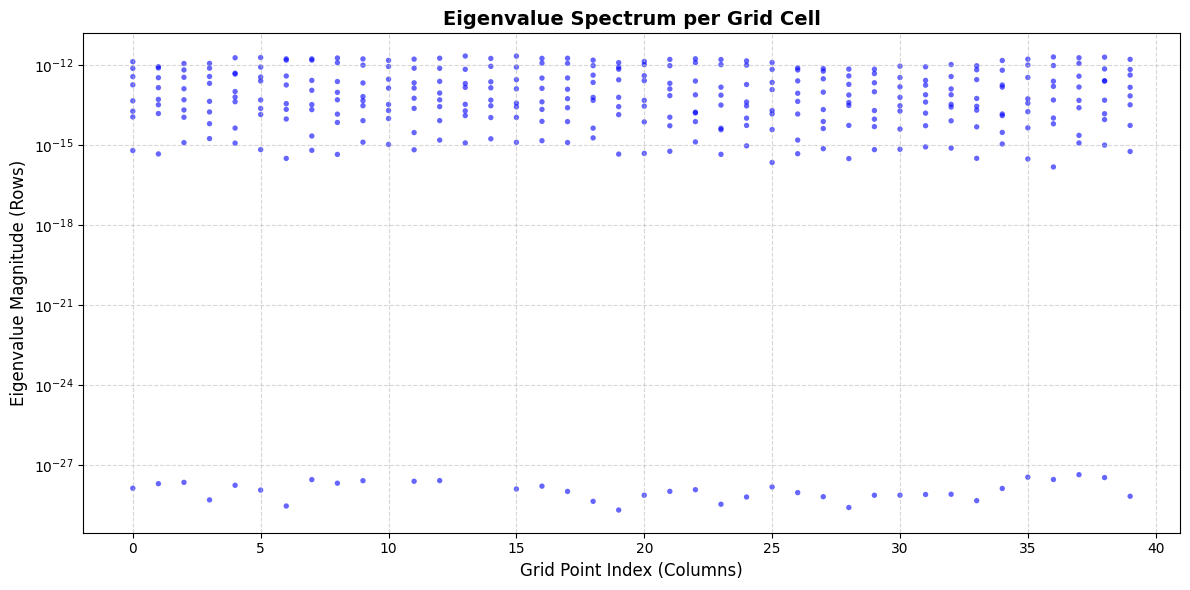

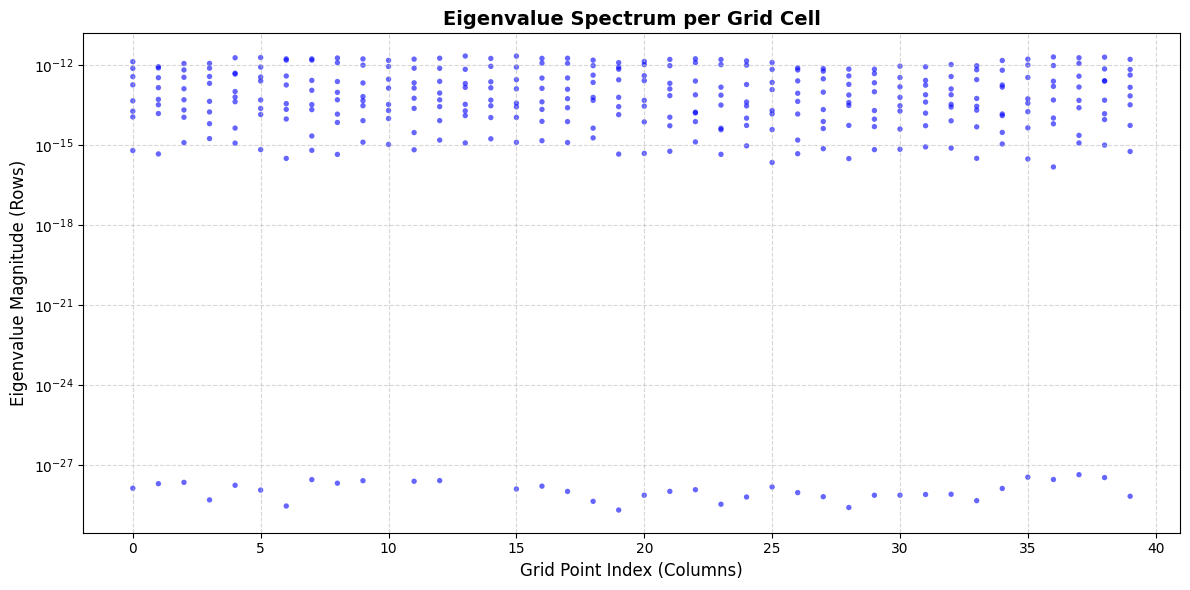

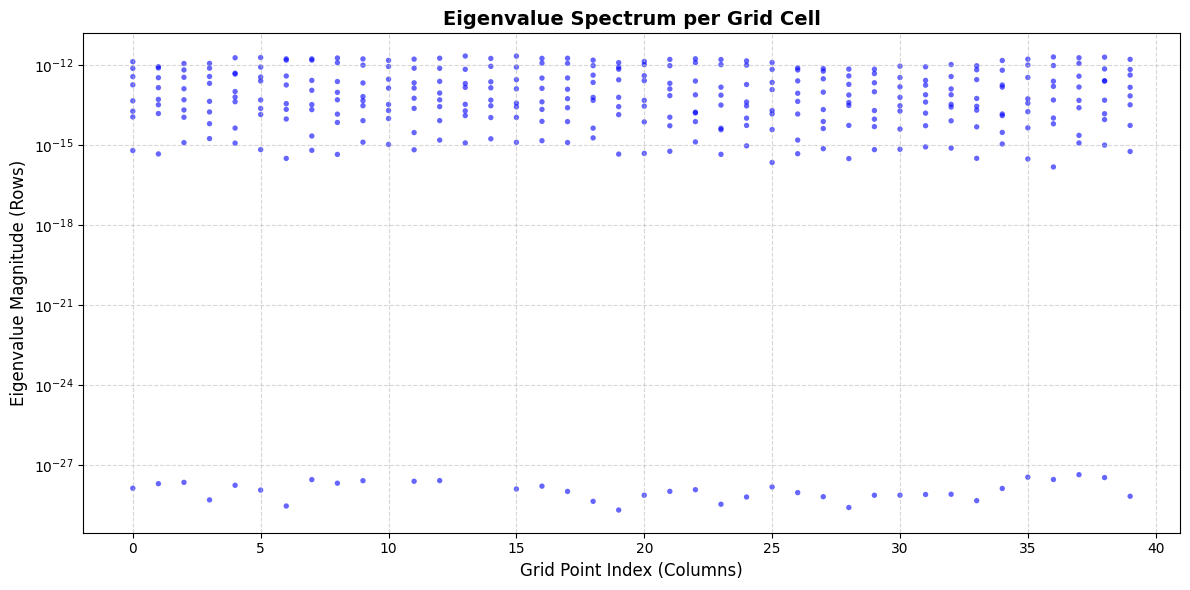

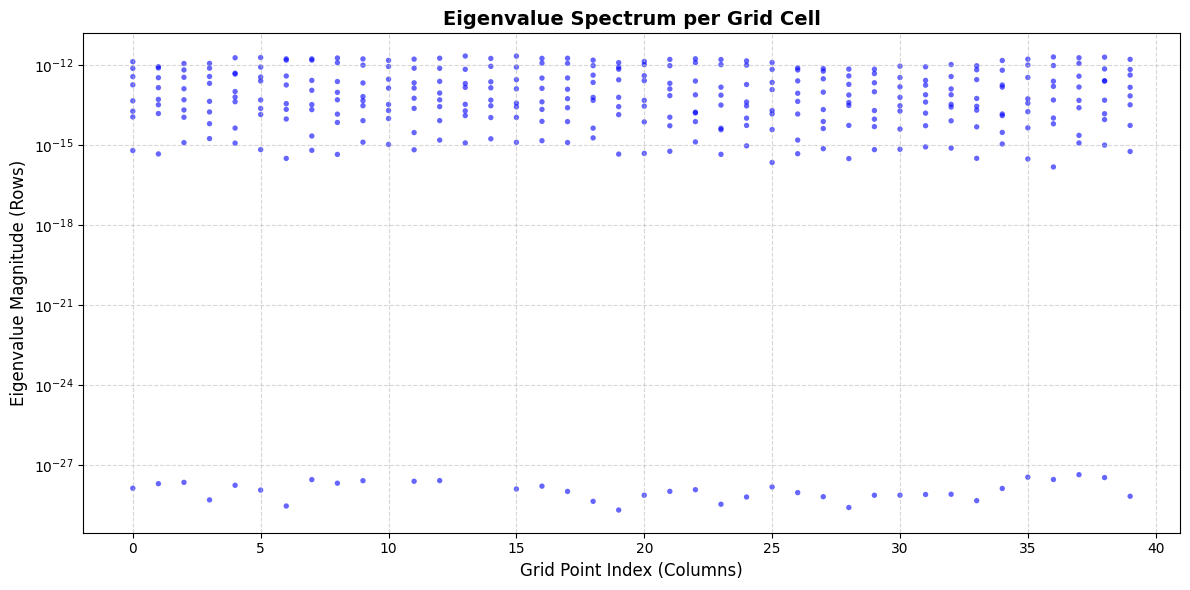

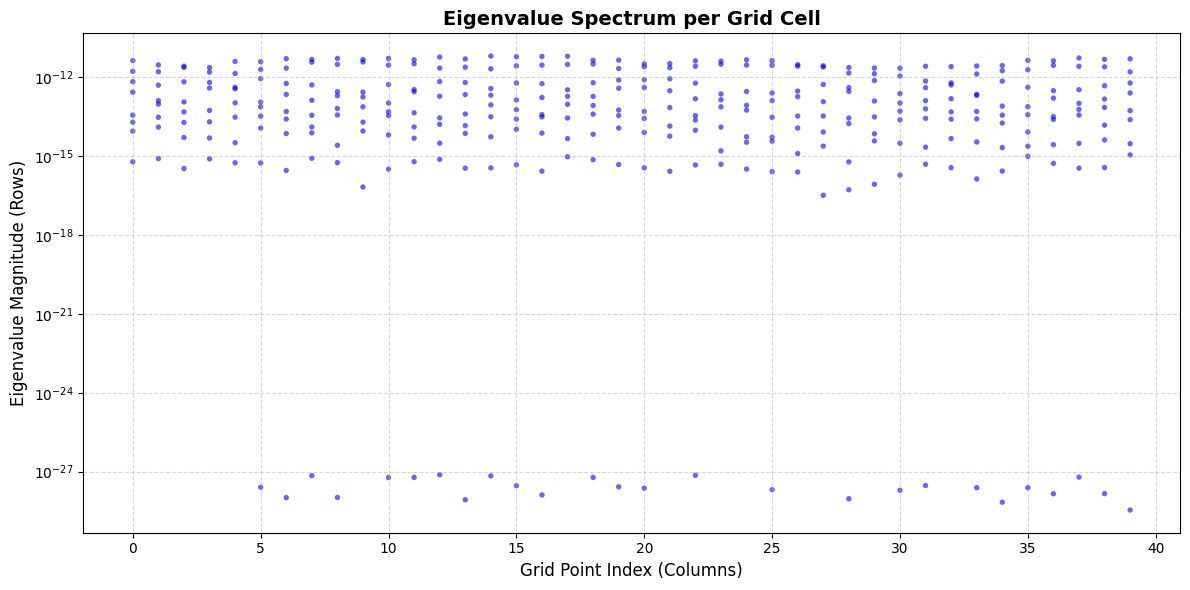

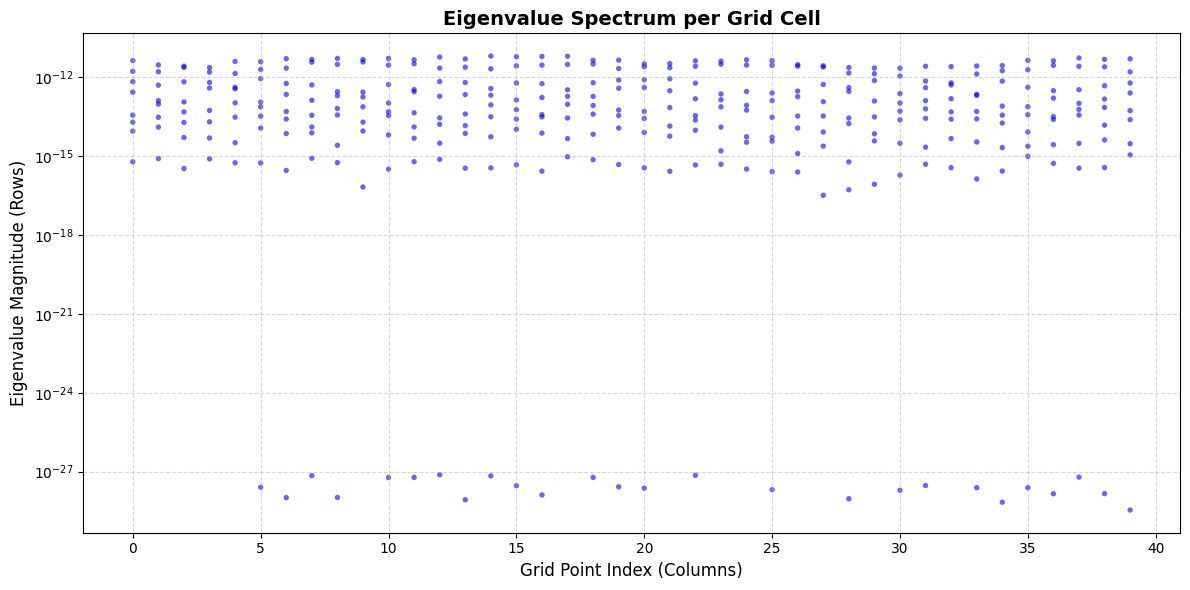

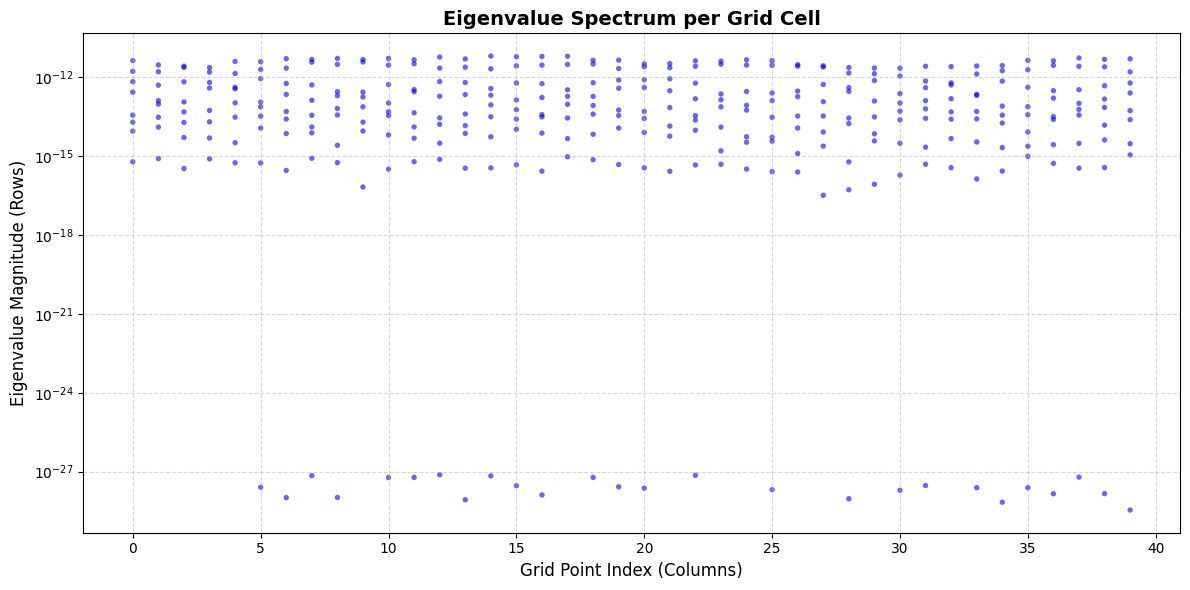

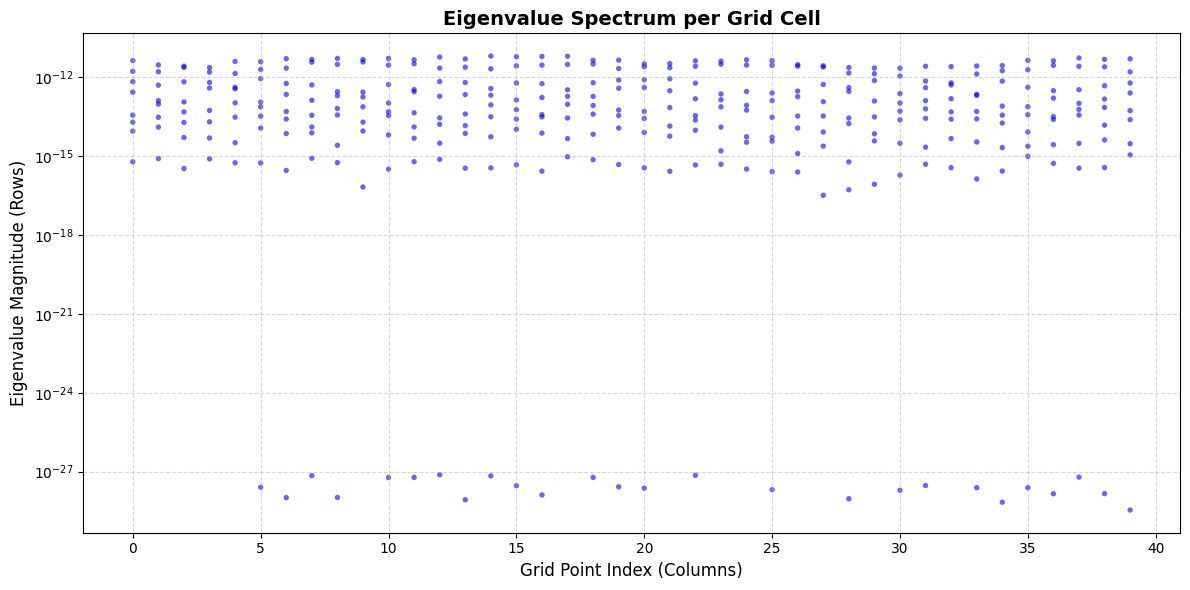

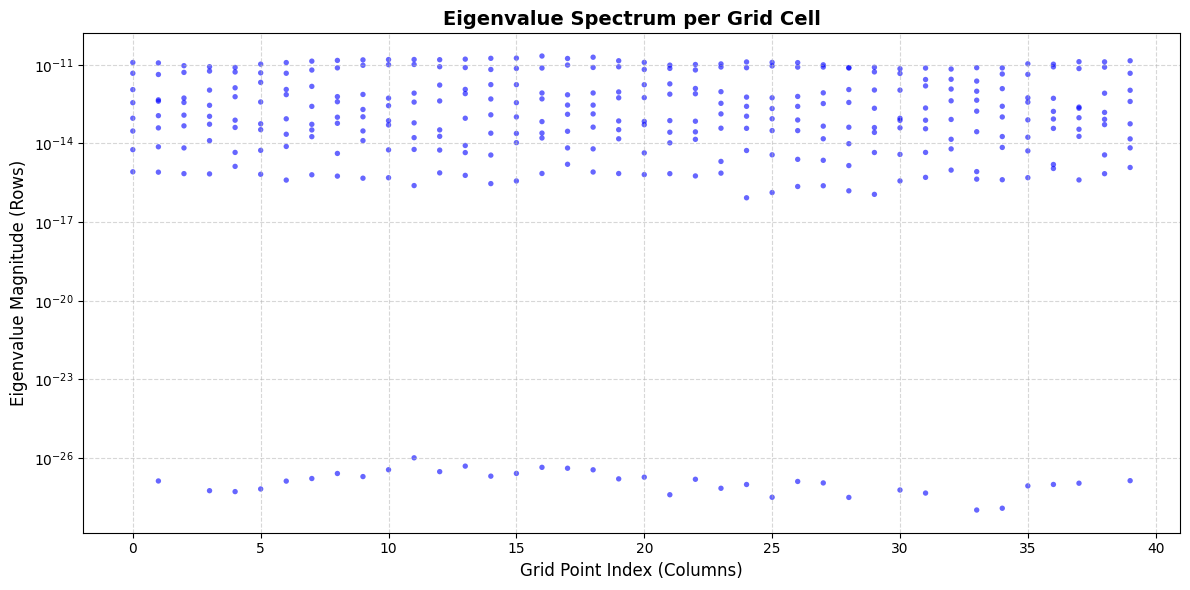

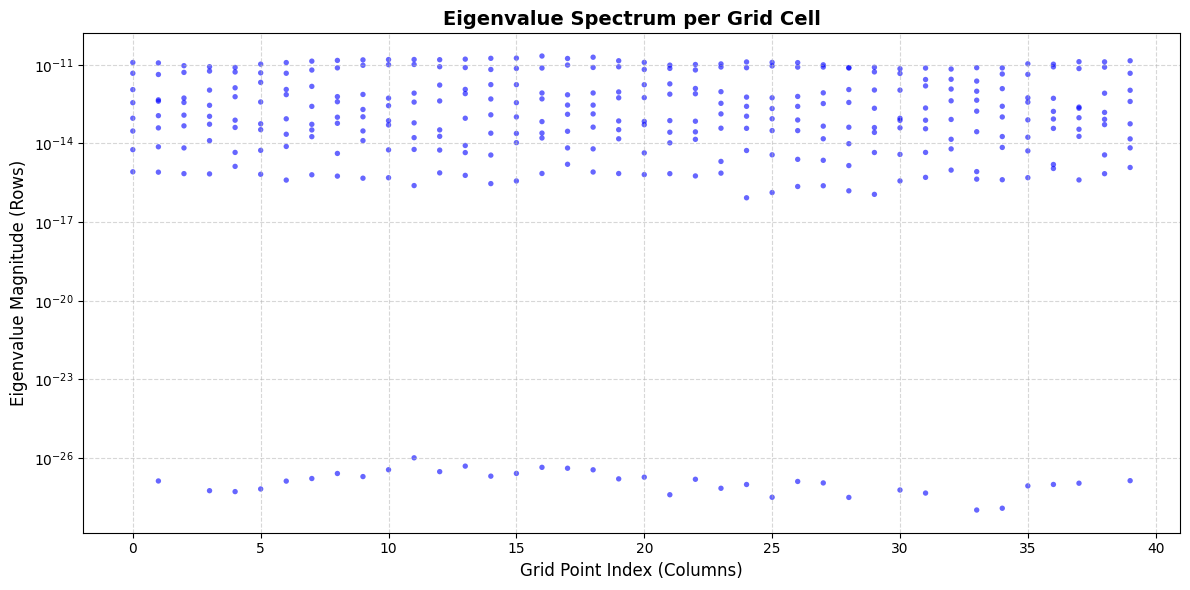

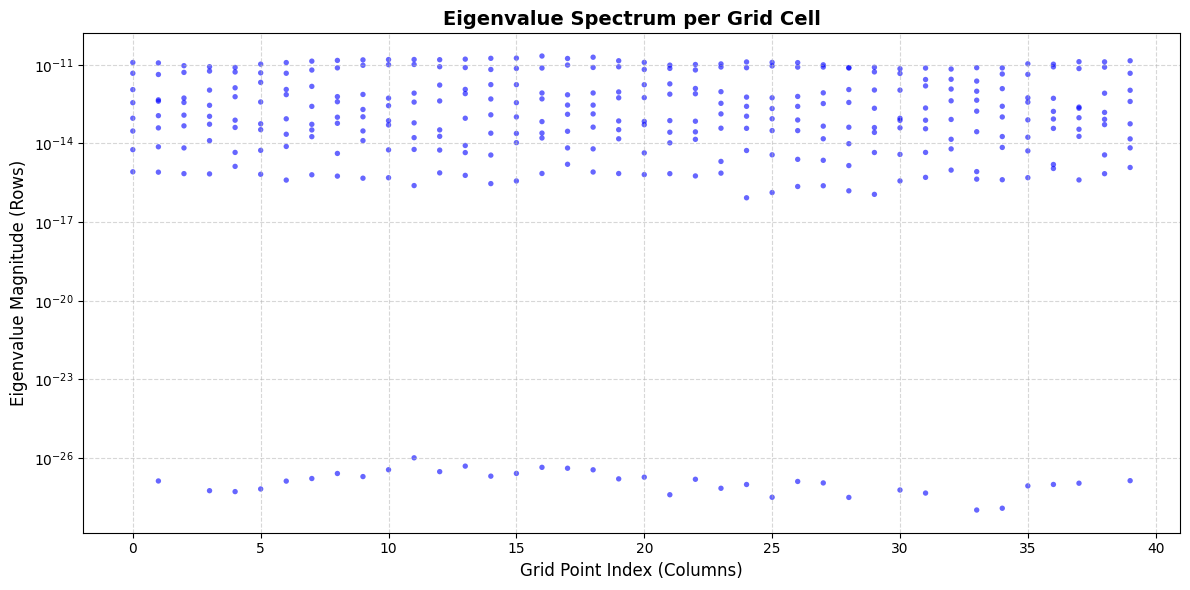

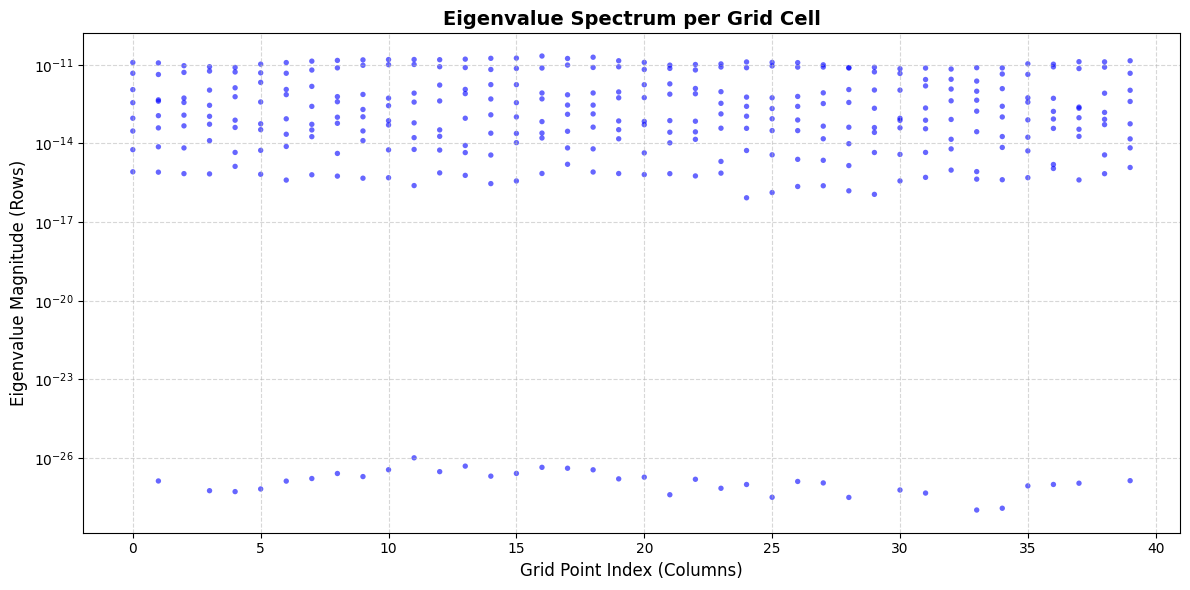

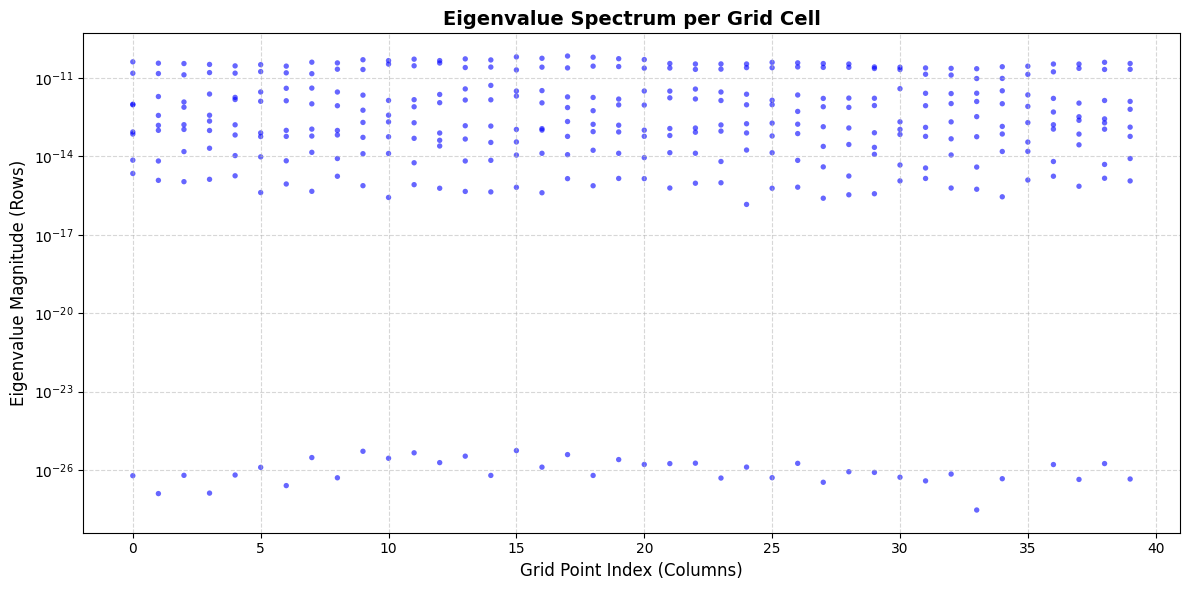

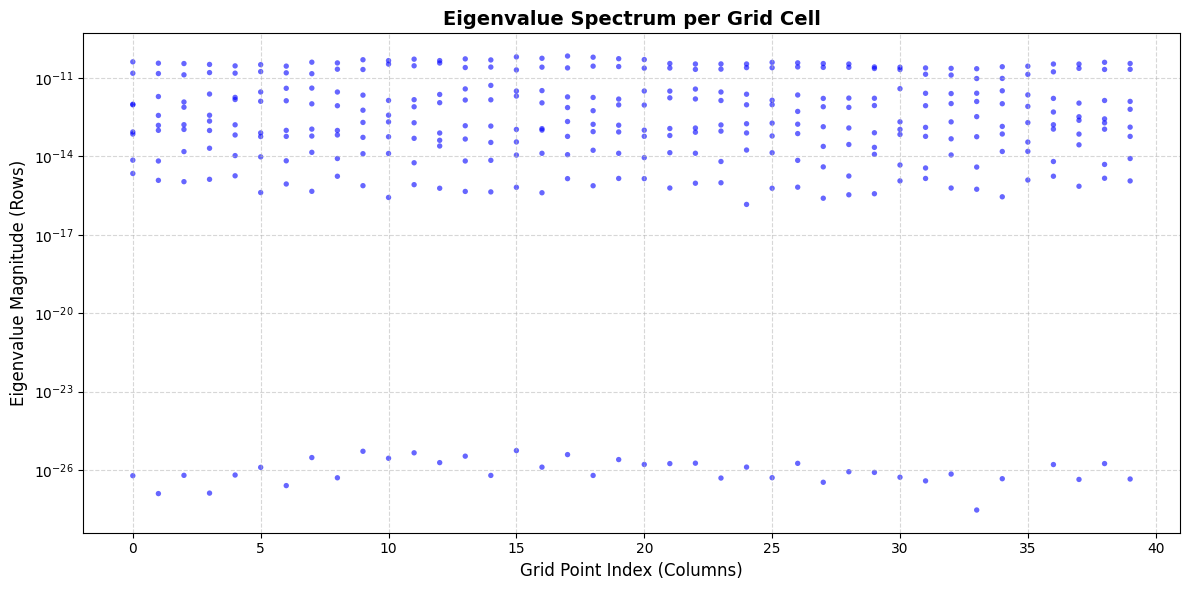

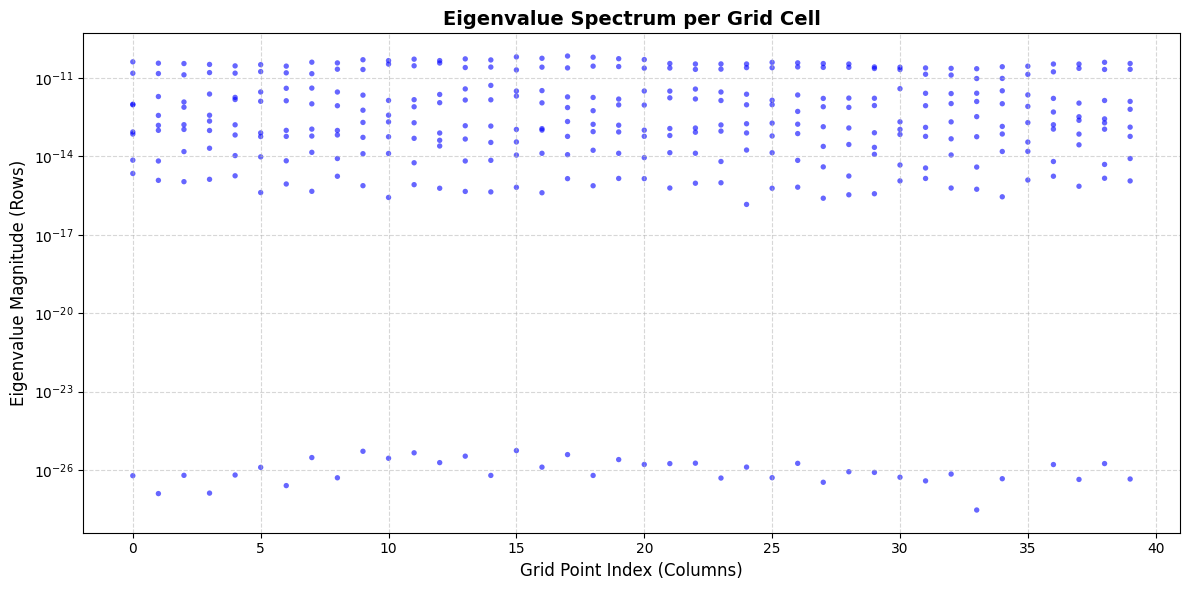

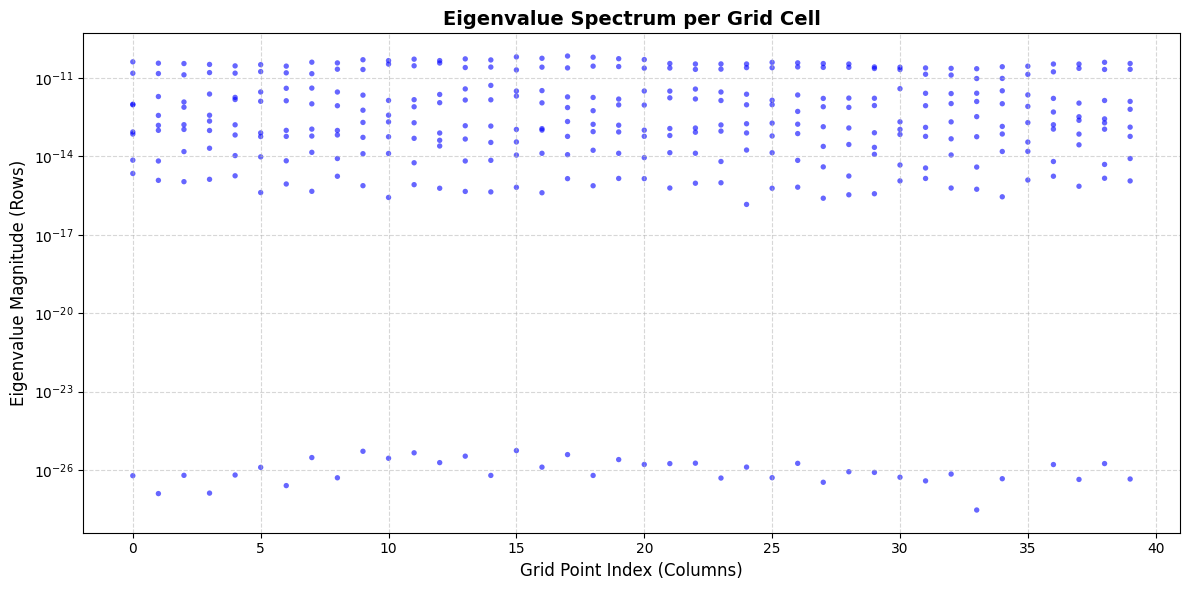

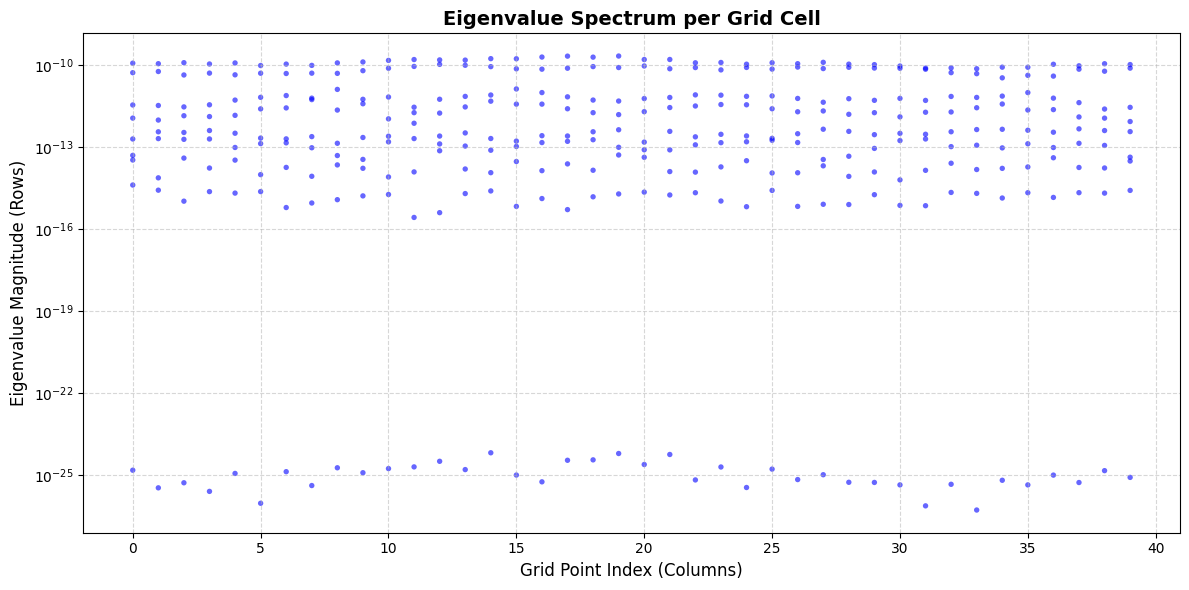

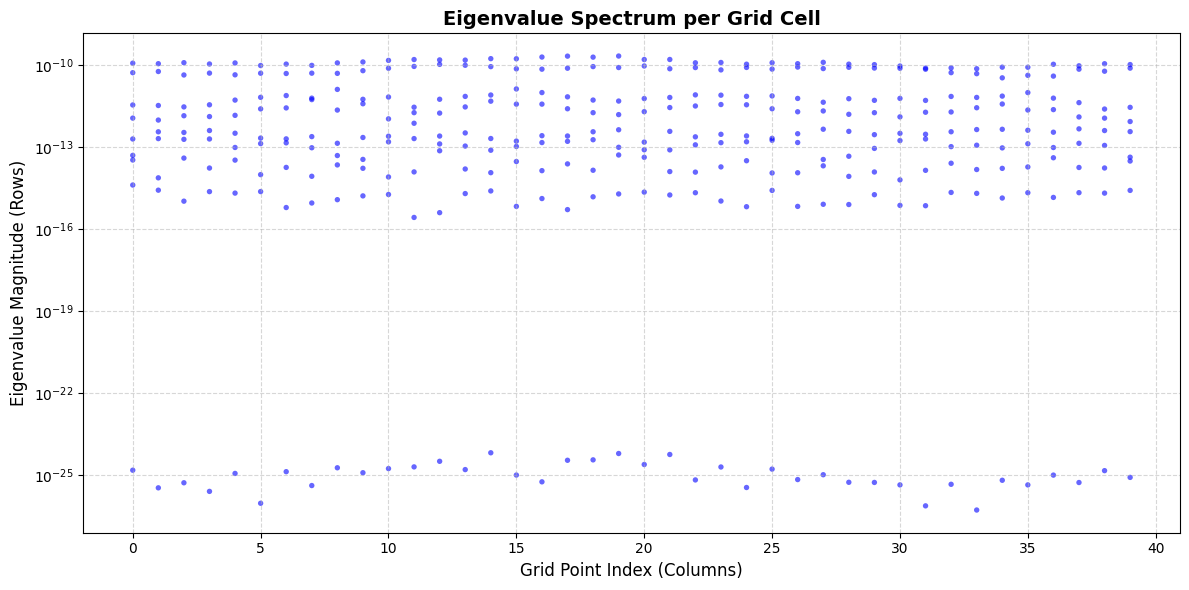

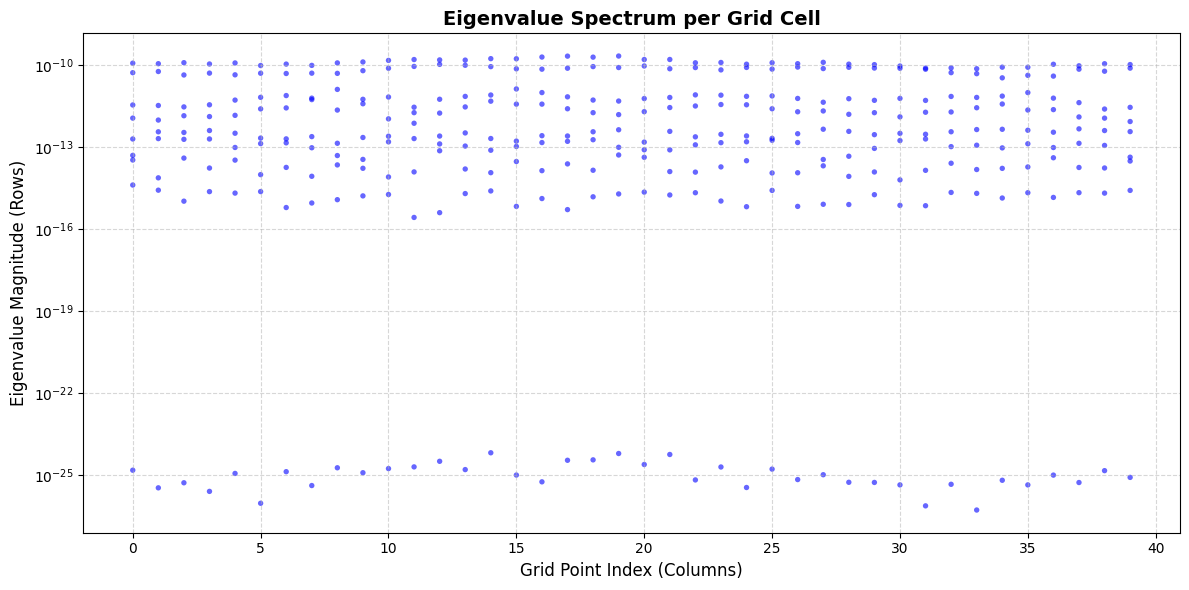

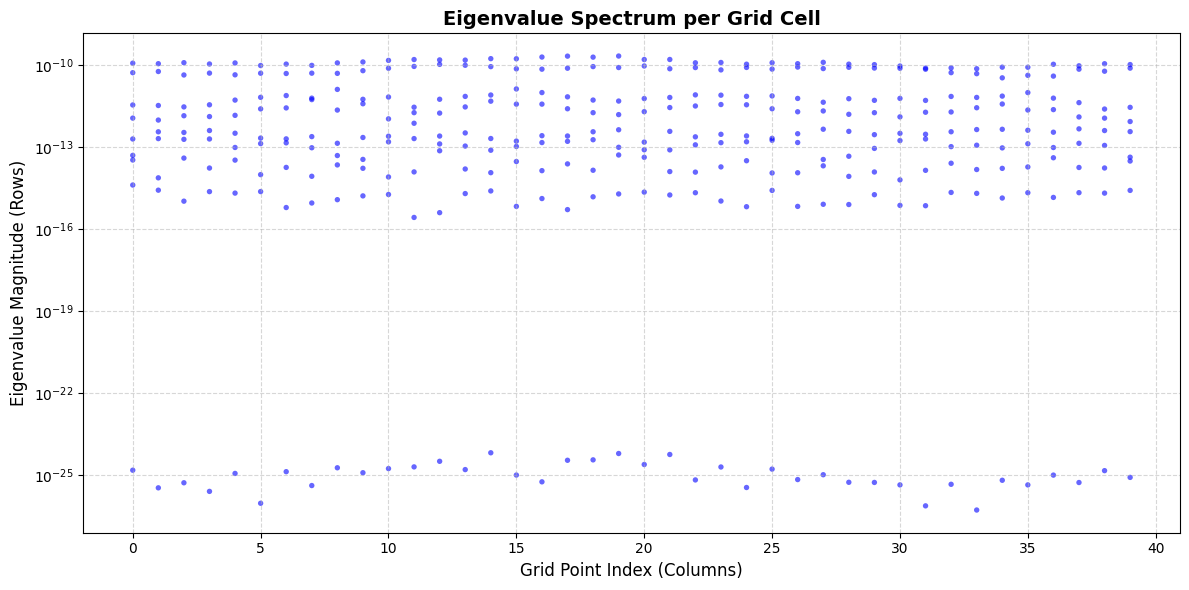

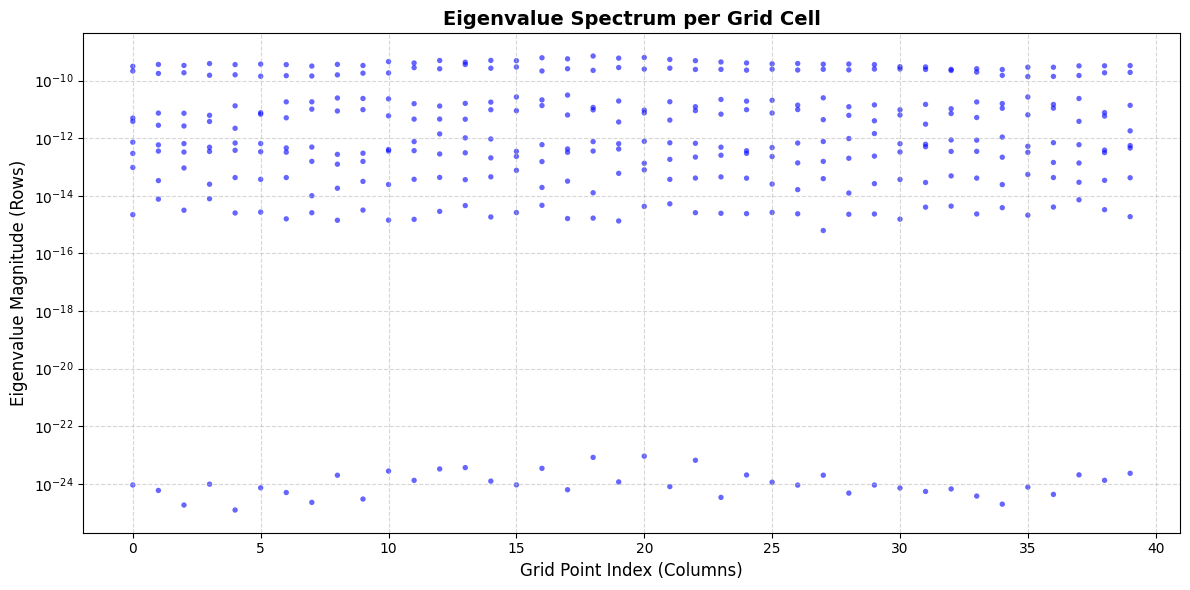

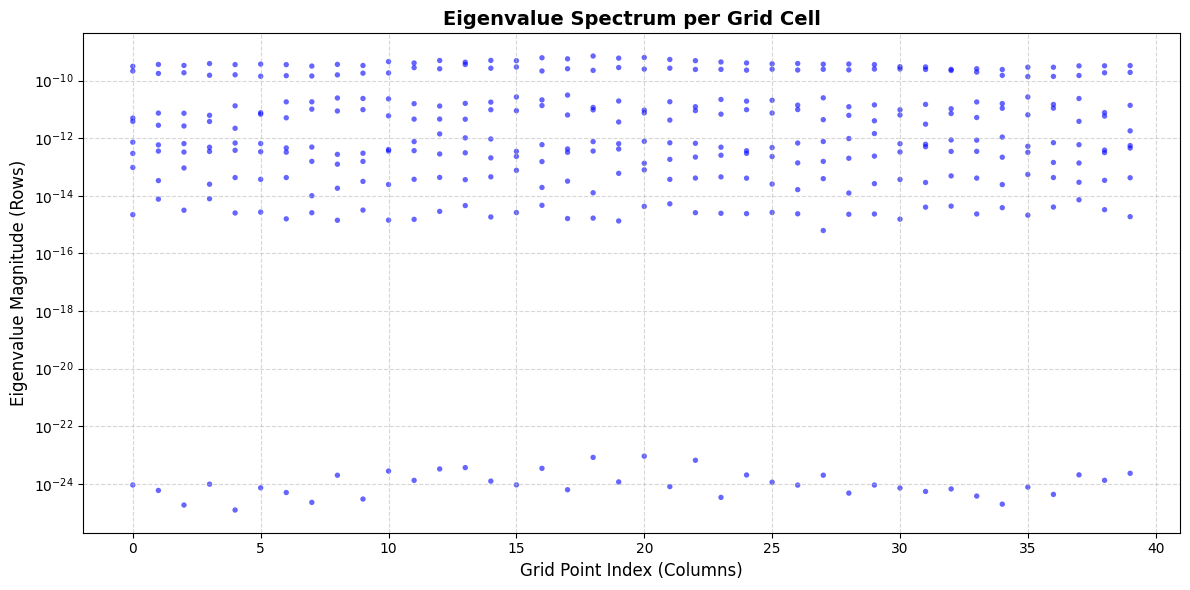

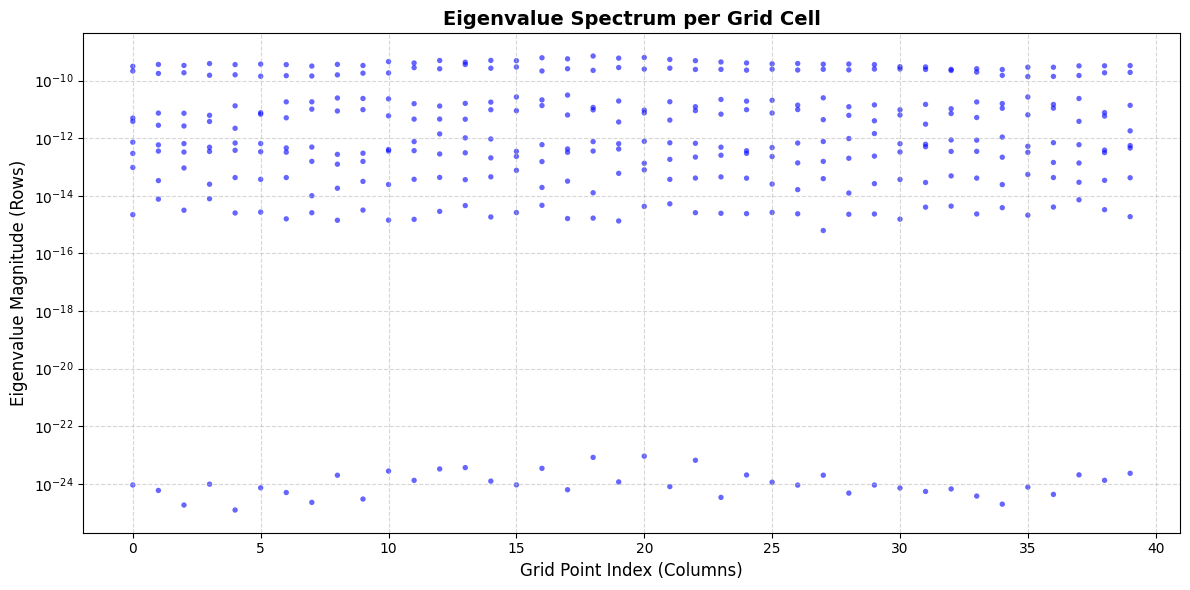

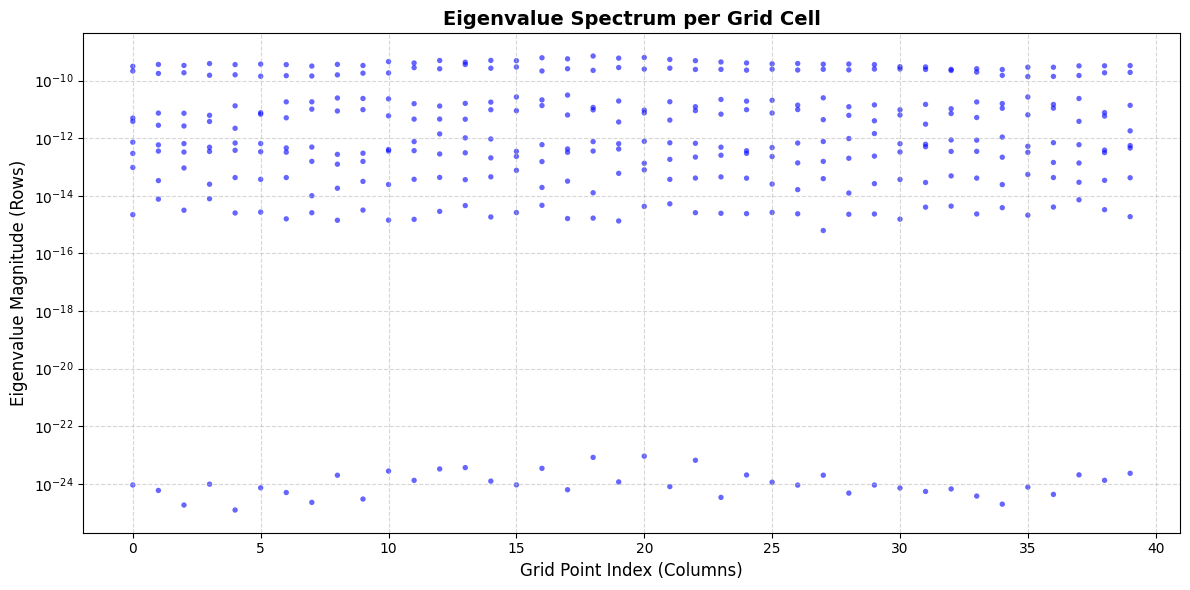

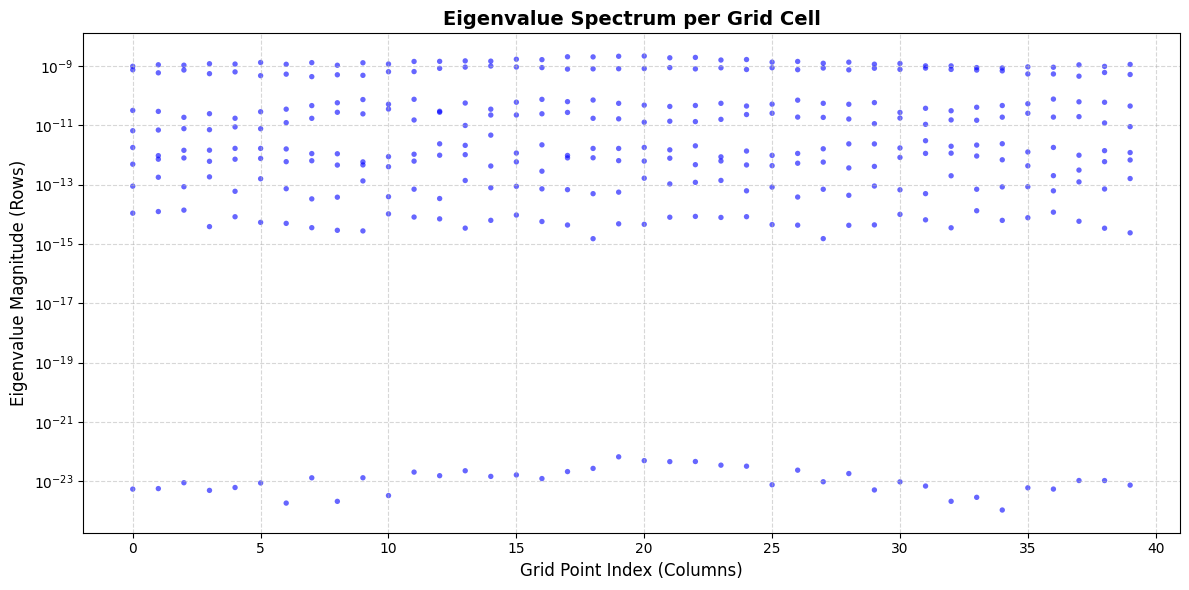

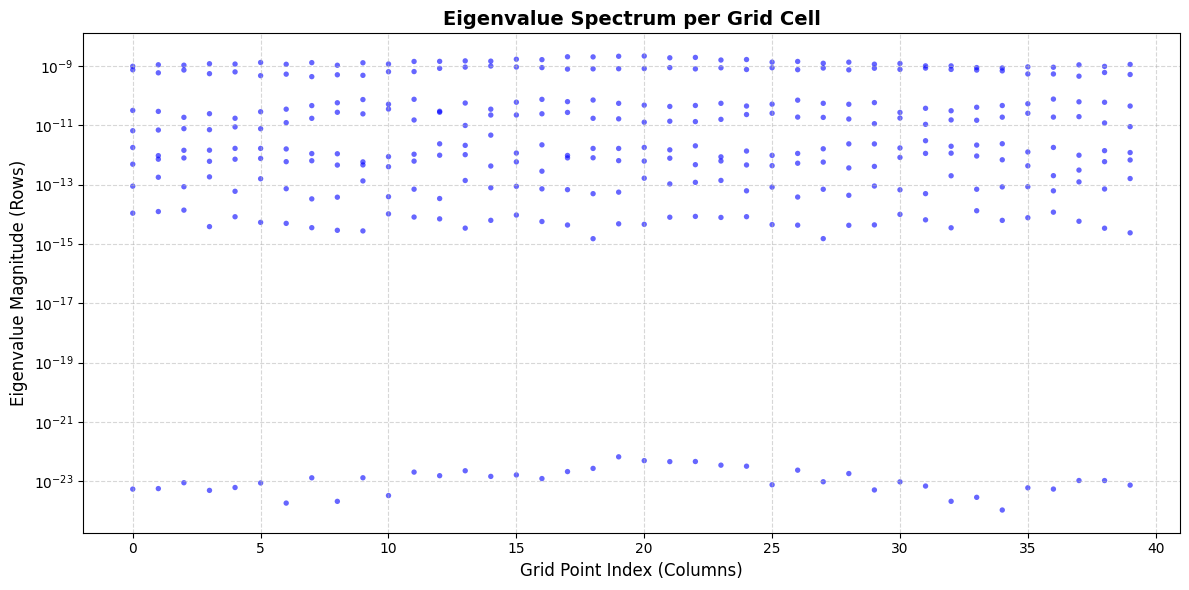

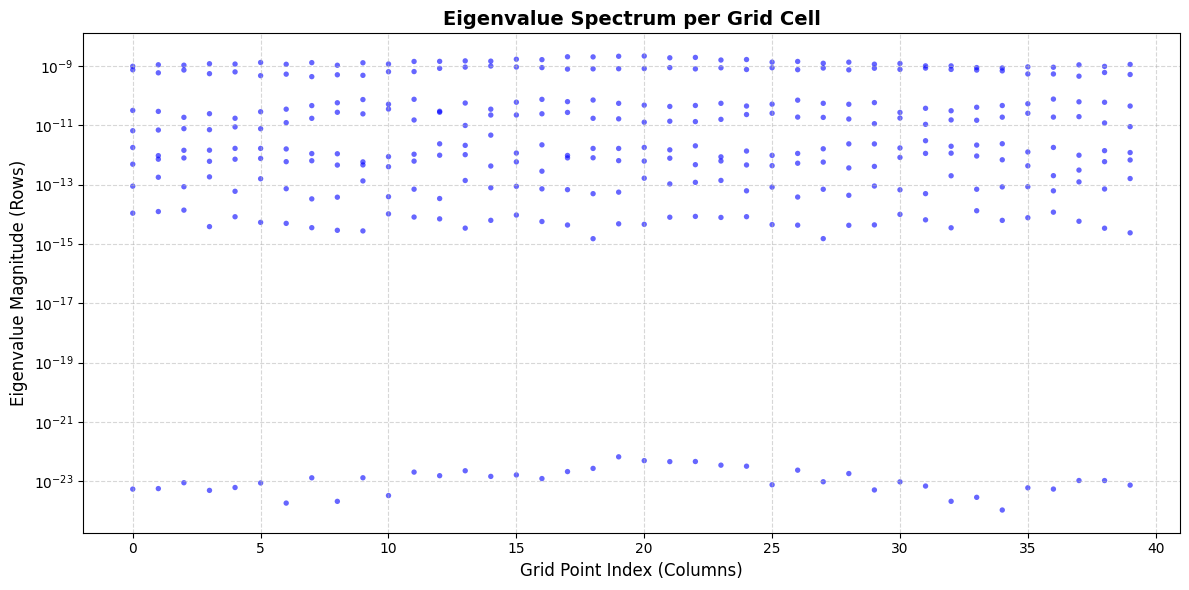

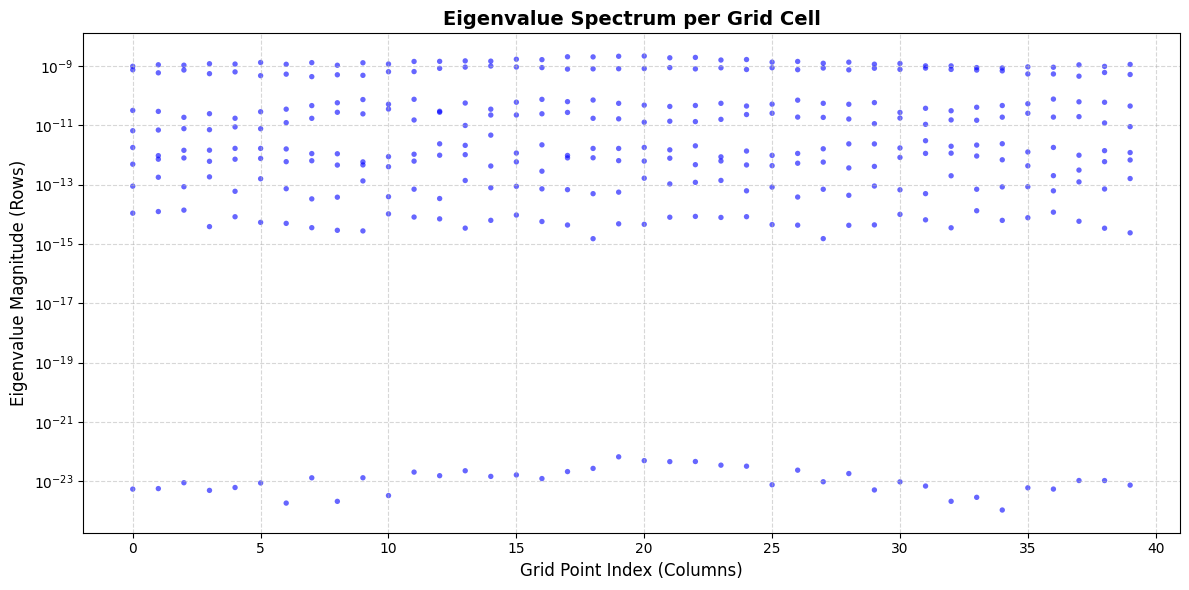

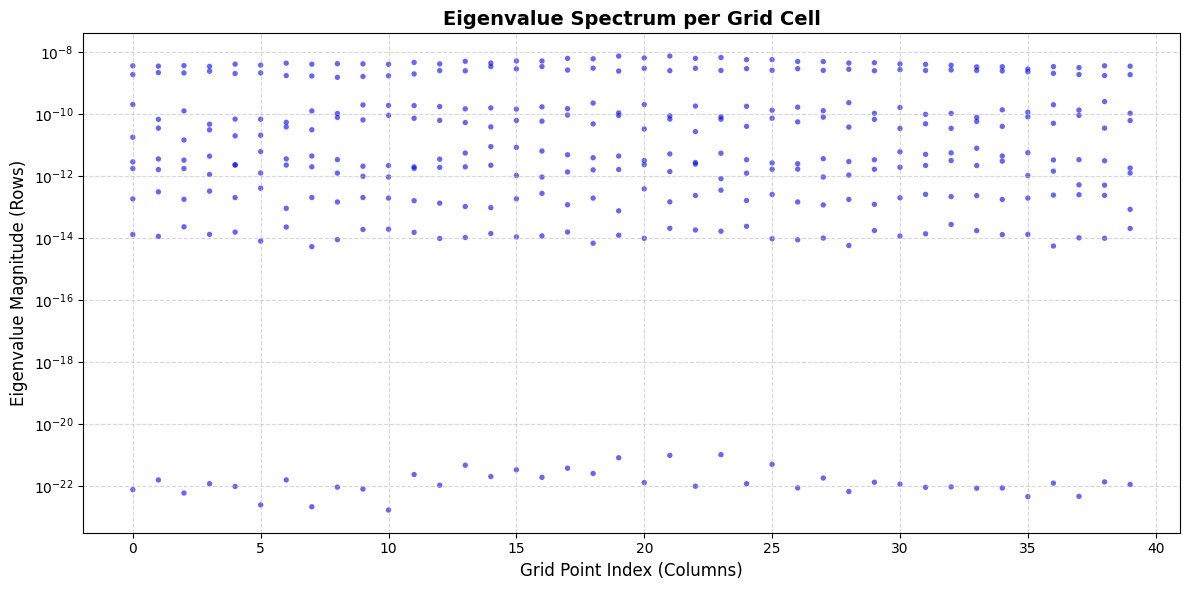

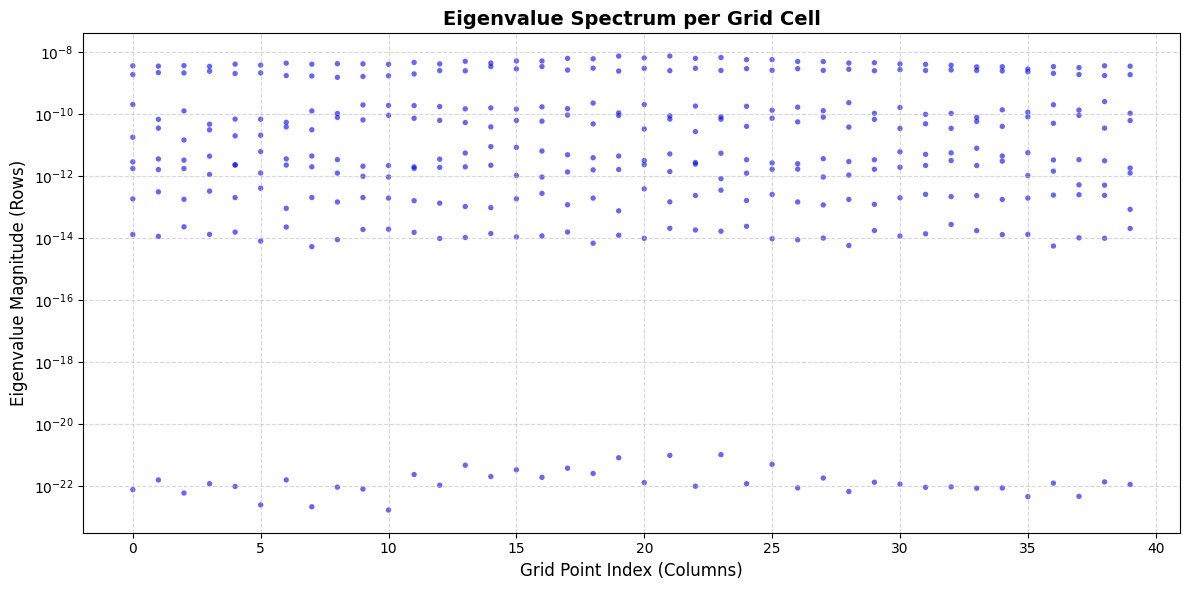

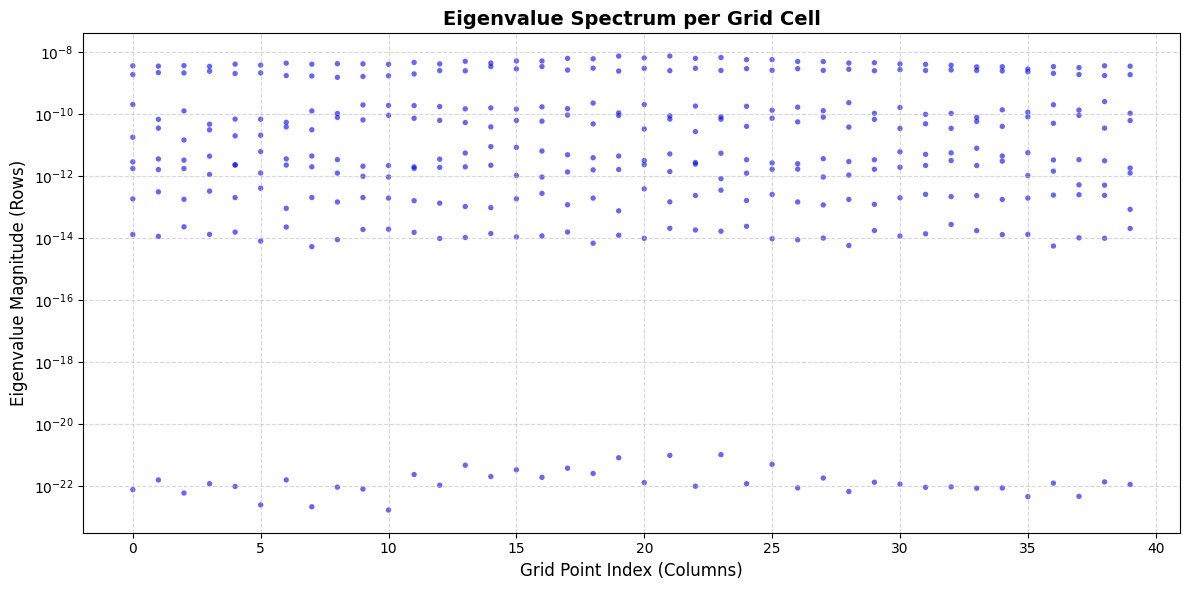

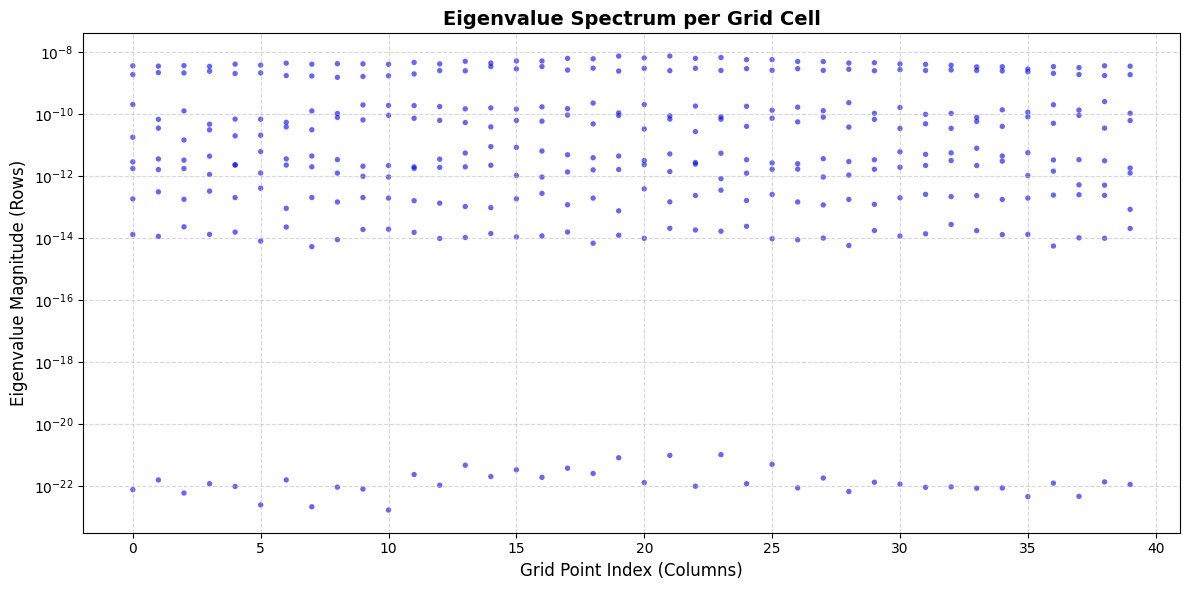

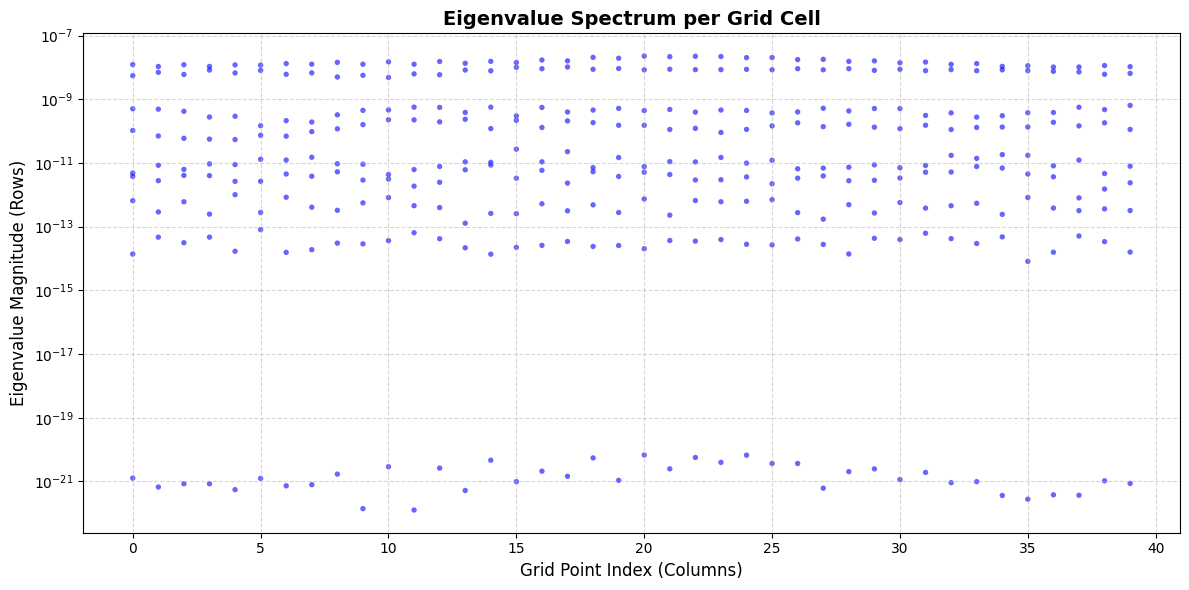

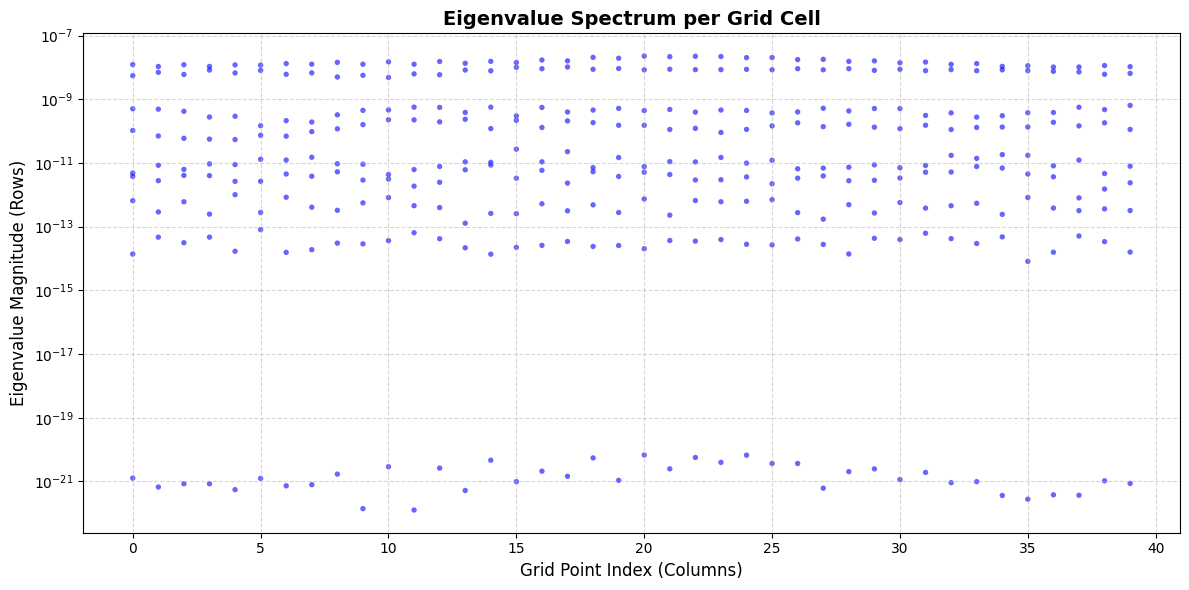

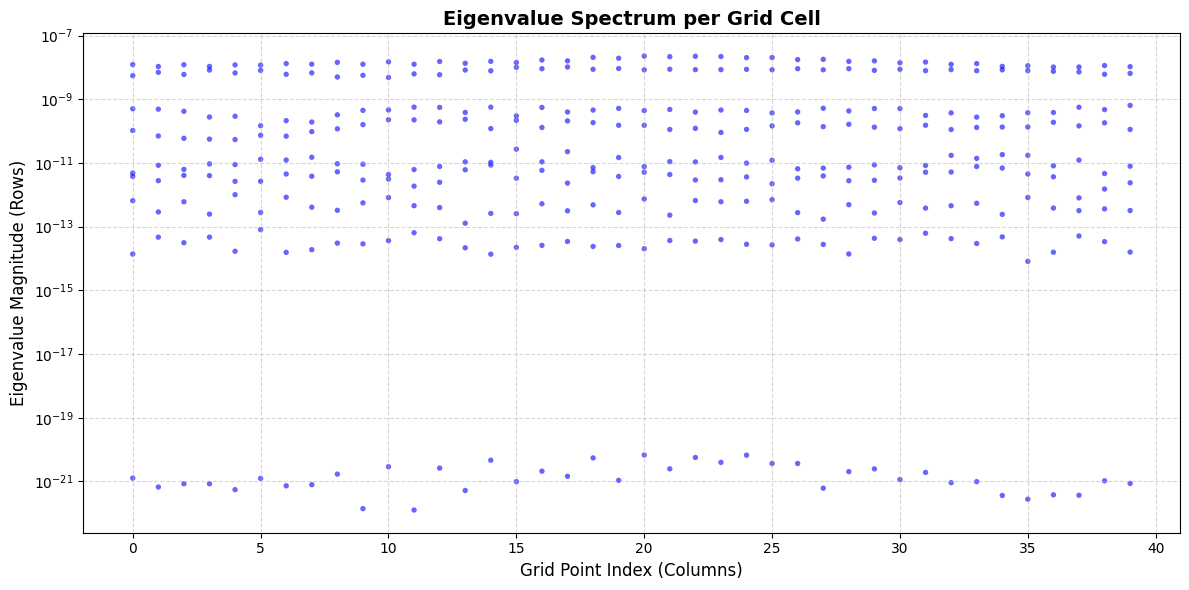

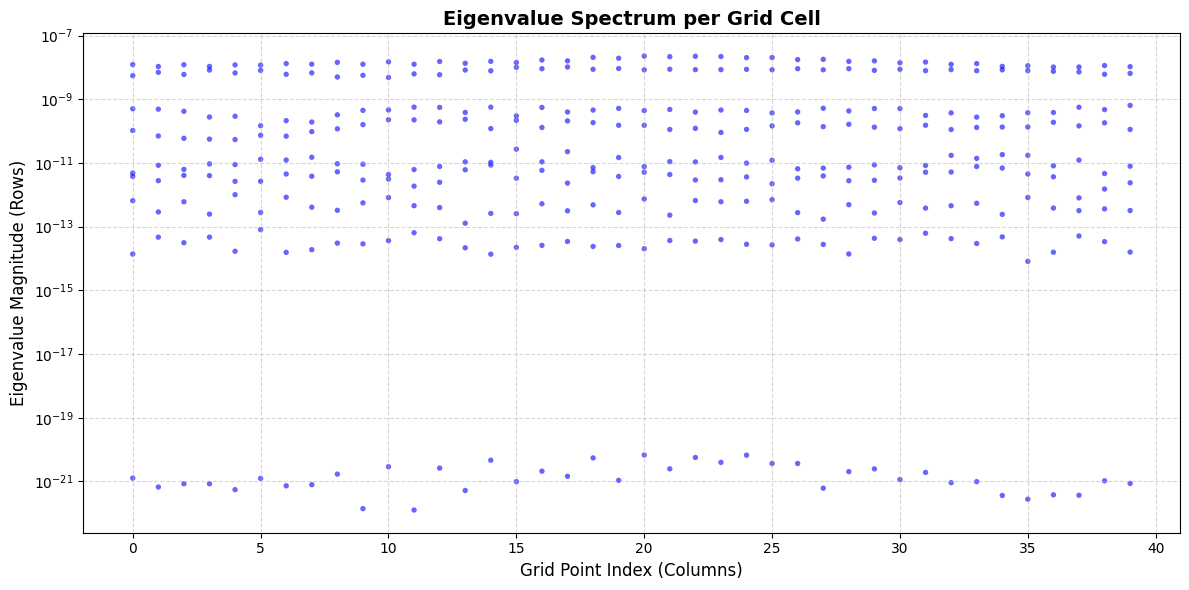

In [7]:
# Now that we have our ensembles generated we need to generate the LETLM, IETLM and GETLM for each time step
GETLMS_1= []
GETLMS_2= []
GETLMS_3= []
GETLMS_4= []

IETLMS = []
LETLMS = []

for i in range(len(Ensemble_final)-2):
    # We start by selecting the ensembles at each time level
    Chi = Ensemble_final[i+2]  # Future step matrix (N, ensemble_size)
    Xi  = Ensemble_final[i+1]  # Current step matrix (N, ensemble_size)
    X   = Ensemble_final[i]
    k1 = 1 # number of zero eigenvalue eigenvalues
    k2 = 2 # number of zero eigenvalue eigenvalues
    k3 = 3 # number of zero eigenvalue eigenvalues
    k4 = 4 # number of zero eigenvalue eigenvalues

    # We now make the GETLM
    N_tilde_G, L_tilde_G, K_tilde_G = GETLMC.GETLM_generator(Chi, Xi, X, stencil_members_large_CN, model_parameters, ensemble_size_CN, k1, plot = True)
    GETLMS_1.append([N_tilde_G, L_tilde_G, K_tilde_G])

    N_tilde_G, L_tilde_G, K_tilde_G = GETLMC.GETLM_generator(Chi, Xi, X, stencil_members_large_CN, model_parameters, ensemble_size_CN, k2, plot = True)
    GETLMS_2.append([N_tilde_G, L_tilde_G, K_tilde_G])

    N_tilde_G, L_tilde_G, K_tilde_G = GETLMC.GETLM_generator(Chi, Xi, X, stencil_members_large_CN, model_parameters, ensemble_size_CN, k3, plot = True)
    GETLMS_3.append([N_tilde_G, L_tilde_G, K_tilde_G])

    N_tilde_G, L_tilde_G, K_tilde_G = GETLMC.GETLM_generator(Chi, Xi, X, stencil_members_large_CN, model_parameters, ensemble_size_CN, k4, plot = True)
    GETLMS_4.append([N_tilde_G, L_tilde_G, K_tilde_G])

    # We will now make the IETLM
    N_tilde_I, L_tilde_I = IETLMC.IETLM_generator(Chi, Xi, IETLM_STENCIL_LARGE, model_parameters, ensemble_size_CN)
    IETLM_temp = torch.pinverse(N_tilde_I) @ L_tilde_I
    IETLMS.append(IETLM_temp)

    # We will now make the LETLM
    M_tilde = LETLMC.LETLM_generator(Chi, Xi, LETLM_STENCIL_LARGE, model_parameters, ensemble_size_CN)
    LETLMS.append(M_tilde)


tensor(0.)


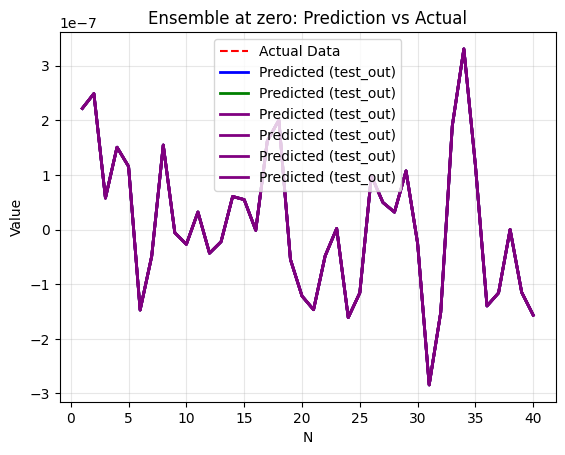

tensor(0.0164)


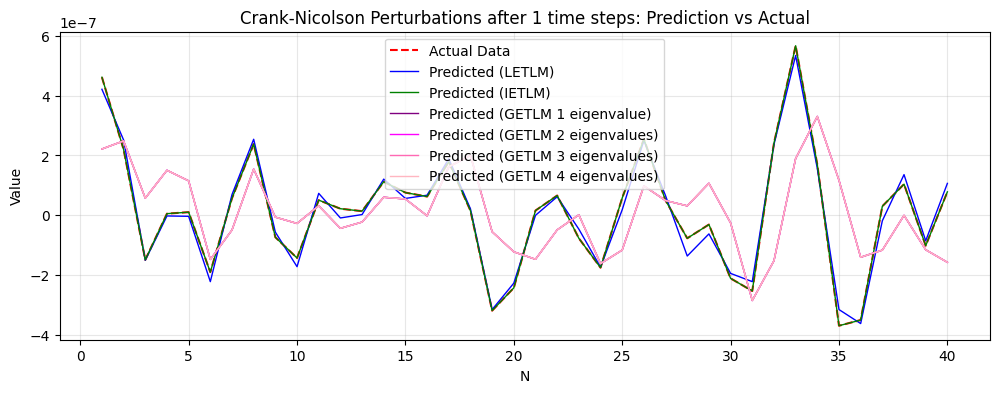

tensor(0.0355)


<Figure size 640x480 with 0 Axes>

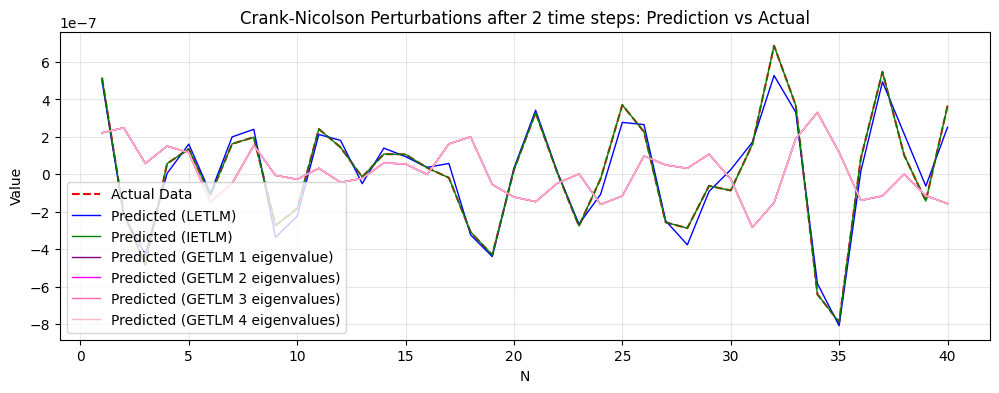

tensor(0.0572)


<Figure size 640x480 with 0 Axes>

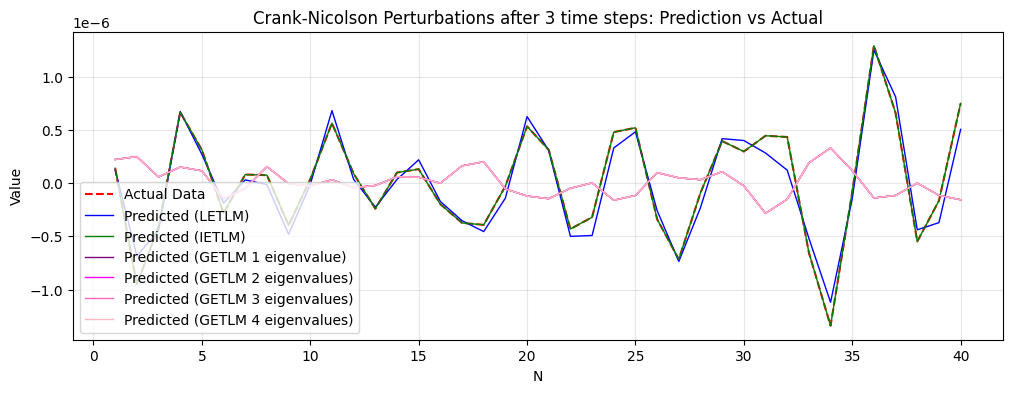

tensor(0.0740)


<Figure size 640x480 with 0 Axes>

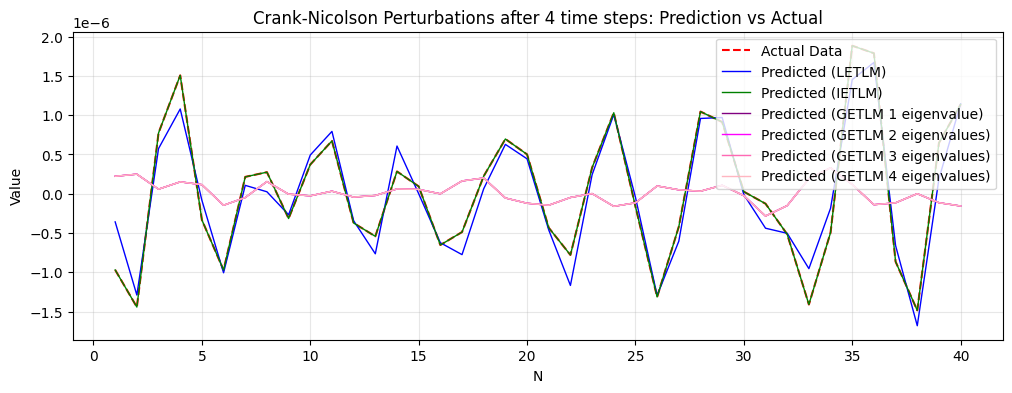

tensor(0.0885)


<Figure size 640x480 with 0 Axes>

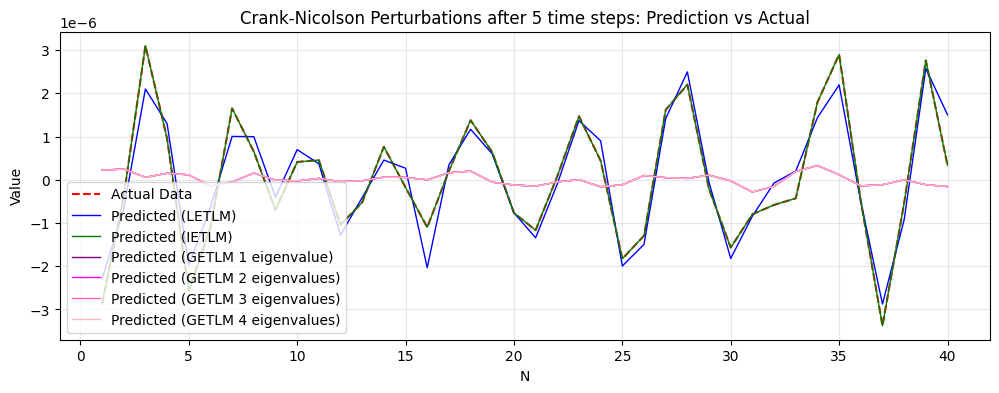

tensor(0.1410)


<Figure size 640x480 with 0 Axes>

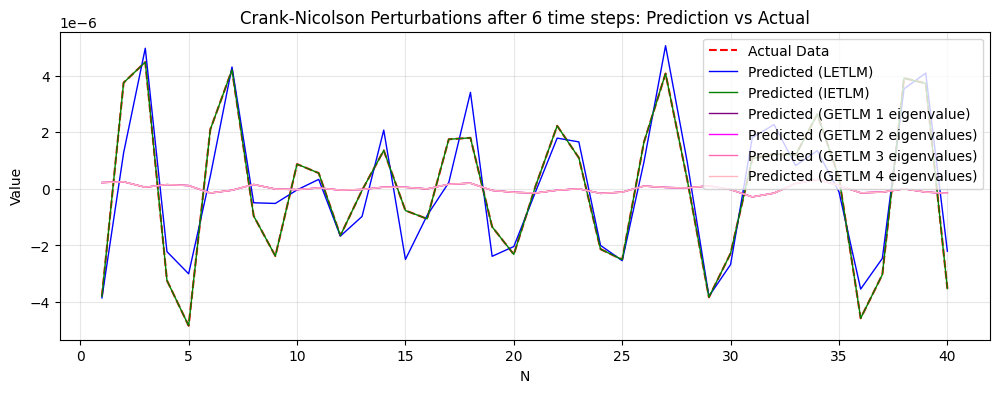

tensor(0.3277)


<Figure size 640x480 with 0 Axes>

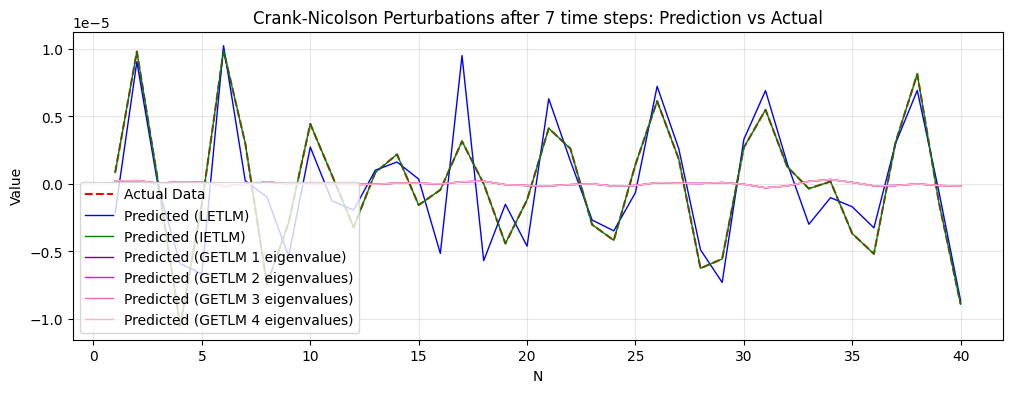

tensor(1.3328)


<Figure size 640x480 with 0 Axes>

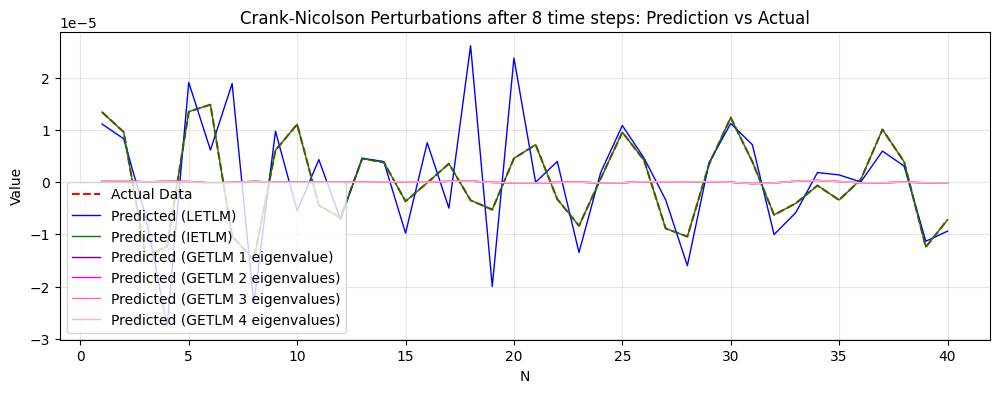

tensor(6.0348)


<Figure size 640x480 with 0 Axes>

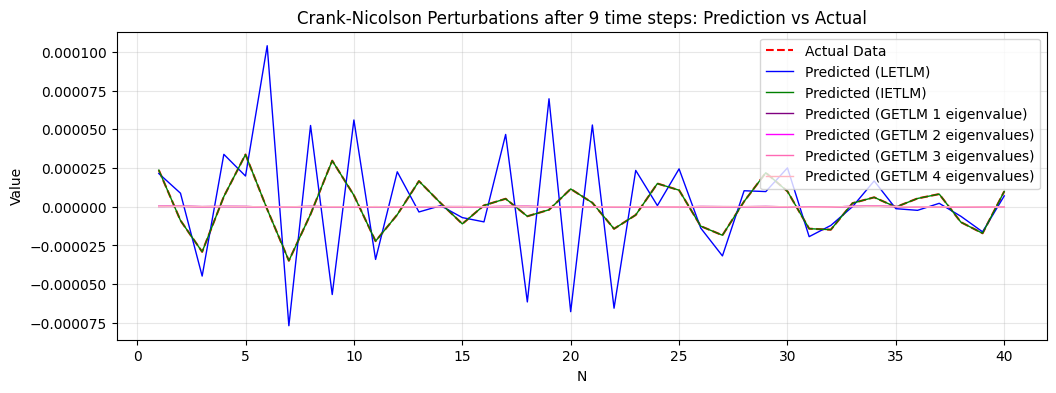

<Figure size 640x480 with 0 Axes>

In [17]:
# We will now compare the TLMS to the actual data to see 

# We first set a starting point for the TLMS
starting_time = 1

x_values = np.arange(1, N + 1)

LETLM_norm= []
IETLM_norm = []
GETLM_norm = []


LETLM_TT_result = []
IETLM_TT_result = []
GETLM_1_TT_result = []
GETLM_2_TT_result = []
GETLM_3_TT_result = []
GETLM_4_TT_result = []



# The first step is to get the test perturbation and then copy it for the IETLM, LETlM and GETLM 
test_0 = test_final_pert[1+starting_time]
LETLM_test = test_0
IETLM_test = test_0


GETLM_test_future_1 = test_0
GETLM_test_future_2 = test_0
GETLM_test_future_3 = test_0
GETLM_test_future_4 = test_0


GETLM_test_current_1 = test_final_pert[1+starting_time]
GETLM_test_current_2 = test_final_pert[1+starting_time]
GETLM_test_current_3 = test_final_pert[1+starting_time]
GETLM_test_current_4 = test_final_pert[1+starting_time]


letlm_norm = L2_norm(LETLM_test, test_0)
ietlm_norm = L2_norm(IETLM_test, test_0)
# getlm_norm = L2_norm(GETLM_test_future, test_0)



LETLM_norm.append(letlm_norm)
IETLM_norm.append(ietlm_norm)
# GETLM_norm.append(getlm_norm)

index = 1+starting_time

LETLM_TT = TT.TLM_test(test_guess[index], unpert_run[index], test_0 )
IETLM_TT = TT.TLM_test(test_guess[index], unpert_run[index], test_0 )

GETLM_1_TT = TT.TLM_test(test_guess[index], unpert_run[index], test_0 )
GETLM_2_TT = TT.TLM_test(test_guess[index], unpert_run[index], test_0 )
GETLM_3_TT = TT.TLM_test(test_guess[index], unpert_run[index], test_0 )
GETLM_4_TT = TT.TLM_test(test_guess[index], unpert_run[index], test_0 )



print(LETLM_TT)
LETLM_TT_result.append(LETLM_TT)
IETLM_TT_result.append(IETLM_TT)

GETLM_1_TT_result.append(GETLM_1_TT)
GETLM_2_TT_result.append(GETLM_2_TT)
GETLM_3_TT_result.append(GETLM_3_TT)
GETLM_4_TT_result.append(GETLM_4_TT)





plt.plot(x_values, test_0.detach().cpu().numpy(), label='Actual Data', color='red', linestyle='--')
plt.plot(x_values, LETLM_test.detach().cpu().numpy(), label='Predicted (test_out)', color='blue', linewidth=2)
plt.plot(x_values, IETLM_test.detach().cpu().numpy(), label='Predicted (test_out)', color='green', linewidth=2)

plt.plot(x_values, GETLM_test_future_1.detach().cpu().numpy(), label='Predicted (test_out)', color='purple', linewidth=2)
plt.plot(x_values, GETLM_test_future_2.detach().cpu().numpy(), label='Predicted (test_out)', color='purple', linewidth=2)
plt.plot(x_values, GETLM_test_future_3.detach().cpu().numpy(), label='Predicted (test_out)', color='purple', linewidth=2)
plt.plot(x_values, GETLM_test_future_4.detach().cpu().numpy(), label='Predicted (test_out)', color='purple', linewidth=2)

plt.title(f"Ensemble at zero: Prediction vs Actual")
plt.xlabel("N")
plt.ylabel("Value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show() # This creates a fresh window/plot for each step in the loop

# We will now go through the steps to see how each of the TLMS goes 
for i in range(len(test_final_pert)-3):
    index = i+2 + starting_time
    test = test_final_pert[i+2 + starting_time]
    letlm = LETLMS[i+starting_time][0]
    # print(len(letlm))
    LETLM_test = letlm @ LETLM_test

    letlm_tt = TT.TLM_test(test_guess[index], unpert_run[index], LETLM_test)
    print(letlm_tt)
    LETLM_TT_result.append(letlm_tt)
    # LETLM_TT = torch.cat((LETLM_TT, letlm_tt), dim = 0)


    # Ploting the IETLM
    ietlm = IETLMS[i+starting_time]
    IETLM_test = ietlm @ IETLM_test


    ietlm_tt = TT.TLM_test(test_guess[index], unpert_run[index], IETLM_test)
    IETLM_TT_result.append(ietlm_tt)


    # IETLM_TT = torch.cat((IETLM_TT, ietlm_tt), dim = 0)



    GETLM_test_past_1 = GETLM_test_current_1
    GETLM_test_current_1 = GETLM_test_future_1

    GETLM_test_past_2 = GETLM_test_current_2
    GETLM_test_current_2 = GETLM_test_future_2

    GETLM_test_past_3 = GETLM_test_current_3
    GETLM_test_current_3 = GETLM_test_future_3

    GETLM_test_past_4 = GETLM_test_current_4
    GETLM_test_current_4 = GETLM_test_future_4

    NL = torch.pinverse(GETLMS_1[i+starting_time][0]) @ GETLMS_1[i+starting_time][1]
    NK = torch.pinverse(GETLMS_1[i+starting_time][0]) @ GETLMS_1[i+starting_time][2]
    GETLM_test_future = NL @ GETLM_test_current_1 + NK @ GETLM_test_past_1

    NL = torch.pinverse(GETLMS_2[i+starting_time][0]) @ GETLMS_2[i+starting_time][1]
    NK = torch.pinverse(GETLMS_2[i+starting_time][0]) @ GETLMS_2[i+starting_time][2]
    GETLM_test_future = NL @ GETLM_test_current_2 + NK @ GETLM_test_past_2
    
    NL = torch.pinverse(GETLMS_3[i+starting_time][0]) @ GETLMS_3[i+starting_time][1]
    NK = torch.pinverse(GETLMS_3[i+starting_time][0]) @ GETLMS_3[i+starting_time][2]
    GETLM_test_future = NL @ GETLM_test_current_3 + NK @ GETLM_test_past_3

    NL = torch.pinverse(GETLMS_4[i+starting_time][0]) @ GETLMS_4[i+starting_time][1]
    NK = torch.pinverse(GETLMS_4[i+starting_time][0]) @ GETLMS_4[i+starting_time][2]
    GETLM_test_future = NL @ GETLM_test_current_4 + NK @ GETLM_test_past_4

    getlm_tt_1 = TT.TLM_test(test_guess[index], unpert_run[index], GETLM_test_future_1)
    getlm_tt_2 = TT.TLM_test(test_guess[index], unpert_run[index], GETLM_test_future_2)
    getlm_tt_3 = TT.TLM_test(test_guess[index], unpert_run[index], GETLM_test_future_3)
    getlm_tt_4 = TT.TLM_test(test_guess[index], unpert_run[index], GETLM_test_future_4)


    # GETLM_TT = torch.cat((GETLM_TT, getlm_tt), dim = 0)
    GETLM_1_TT_result.append(getlm_tt_1)
    GETLM_2_TT_result.append(getlm_tt_2)
    GETLM_3_TT_result.append(getlm_tt_3)
    GETLM_4_TT_result.append(getlm_tt_4)




    

    # # We now need to calculate the L2 norm

    # letlm_norm = L2_norm(LETLM_test, test)
    # ietlm_norm = L2_norm(IETLM_test, test)
    # getlm_norm = L2_norm(GETLM_test_future, test)
    # print('IETLM norm:', ietlm_norm)
    # print('LETLM norm:', letlm_norm)
    # print('GETLM norm:', getlm_norm)
    # LETLM_norm.append(letlm_norm)
    # IETLM_norm.append(ietlm_norm)
    # GETLM_norm.append(getlm_norm)

    plt.figure(figsize=(12, 4))  # width=12 inches, height=4 inches

    plt.plot(x_values, test.detach().cpu().numpy(), label='Actual Data', color='red', linestyle='--')
    plt.plot(x_values, LETLM_test.detach().cpu().numpy(), label='Predicted (LETLM)', color='blue', linewidth=1)
    plt.plot(x_values, IETLM_test.detach().cpu().numpy(), label='Predicted (IETLM)', color='green', linewidth=1)
    plt.plot(x_values, GETLM_test_future_1.detach().cpu().numpy(), label='Predicted (GETLM 1 eigenvalue)', color='purple', linewidth=1)
    plt.plot(x_values, GETLM_test_future_2.detach().cpu().numpy(), label='Predicted (GETLM 2 eigenvalues)', color='fuchsia', linewidth=1)
    plt.plot(x_values, GETLM_test_future_3.detach().cpu().numpy(), label='Predicted (GETLM 3 eigenvalues)', color='hotpink', linewidth=1)
    plt.plot(x_values, GETLM_test_future_4.detach().cpu().numpy(), label='Predicted (GETLM 4 eigenvalues)', color='lightpink', linewidth=1)



    plt.title(f"Crank-Nicolson Perturbations after {i+1} time steps: Prediction vs Actual")

    plt.xlabel("N")
    plt.ylabel("Value")
    plt.legend()

    plt.grid(True, alpha=0.3)
    plt.show() # This creates a fresh window/plot for each step in the loop
    plt.clf()
    

    
    # plt.plot(x_values, IETLM_test.detach().cpu().numpy() - test.detach().cpu().numpy(), label='Predicted (IETLM)', color='green', linewidth=1)
    # plt.show()
    # plt.clf()



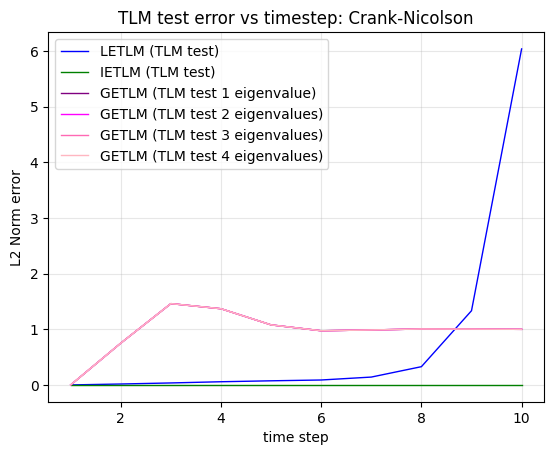

<Figure size 640x480 with 0 Axes>

In [19]:
x_values_norm = np.arange(1,len(IETLM_TT_result)+1)

plt.plot(x_values_norm, LETLM_TT_result, label='LETLM (TLM test)', color='blue', linewidth=1)
plt.plot(x_values_norm, IETLM_TT_result, label='IETLM (TLM test)', color='green', linewidth=1)
plt.plot(x_values_norm, GETLM_1_TT_result, label='GETLM (TLM test 1 eigenvalue)', color='purple', linewidth=1)
plt.plot(x_values_norm, GETLM_2_TT_result, label='GETLM (TLM test 2 eigenvalues)', color='fuchsia', linewidth=1)
plt.plot(x_values_norm, GETLM_3_TT_result, label='GETLM (TLM test 3 eigenvalues)', color='hotpink', linewidth=1)
plt.plot(x_values_norm, GETLM_4_TT_result, label='GETLM (TLM test 4 eigenvalues)', color='lightpink', linewidth=1)

plt.title("TLM test error vs timestep: Crank-Nicolson")
plt.xlabel("time step")
plt.ylabel("L2 Norm error")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show() # This creates a fresh window/plot for each step in the loop
plt.clf()


In [ ]:
x_values_norm = np.arange(1,len(IETLM_norm)+1)
plt.yscale('log')
plt.plot(x_values_norm, LETLM_norm, label='LETLM (L2)', color='blue', linewidth=1)
plt.plot(x_values_norm, IETLM_norm, label='IETLM (L2)', color='green', linewidth=1)
plt.plot(x_values_norm, GETLM_norm, label='GETLM (L2)', color='purple', linewidth=1)


plt.title("L2 norm error vs timestep: Crank-Nicolson")
plt.xlabel("time step")
plt.ylabel("L2 Norm error")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show() # This creates a fresh window/plot for each step in the loop
plt.clf()


In [ ]:
# We will also repeat this for Runge-Kutta 4

# We will start by looking at Crank-Nicolson
# The first step is to the parameters for out model

N = 40 # The number of grid points
dx = 1 # The spacing
F_L96 = 8 # The Lorenz 96 forcing term
dt = 0.05 # This gives a time step of six hours
timesteps =  14400 # This moves the model forward ten years
alpha = 1 # set for no reason
beta = 1 # set for no reason
model_parameters = (N, dx, dt, alpha, beta, F_L96)
model = TST.rk4_L96
x_values = np.arange(1, N+1)  
spin_up_time = 1000

In [ ]:
# we start by initialising the model with a vector of random normal noise
x_in = torch.randn(N,1)
# We then run the model so that the Lorenz 96 model has reached it's 'equilibrium'
for i in tqdm(range(spin_up_time-1)):
    x_in = TST.run_model(x_in, model, model_parameters)

x_out = TST.run_model(x_in, model, model_parameters)

In [ ]:
# Now that the model is spun up, we need to generate the ensembles

# The first step to do this is to work out what we want to use as our stencil
stencil_members_future_RK4 = [-2,-1,0,1]
stencil_members_current_RK4 = [-2,-1,0,1]
stencil_members_past_RK4 = [0]
stencil_members_large_RK4 = [stencil_members_future_RK4, stencil_members_current_RK4, stencil_members_past_RK4]

# Now that we have our stencil we can calculate how many ensemble members we need 
ensemble_size_RK4 = 9 + len(stencil_members_future_RK4) + len(stencil_members_current_RK4) + len(stencil_members_past_RK4)

# We now need to set the size of the perturbation that we will use for generating the ensemble TLMS
SD_pert = 10**(-7)

# We also need to define our test perturbation
Test_pert_current = torch.randn(N) * SD_pert
Test_pert_past = torch.randn(N) * SD_pert
Test_pert = (Test_pert_current, Test_pert_past)

test_final_pert, Ensemble_final, Ensembles, test_guess, unpert_run=  GETLMC.GETLM_ensemble_generator_mult(x_out, ensemble_size_RK4, SD_pert, model, model_parameters, Test_pert, number_of_steps = 20)


In [ ]:
IETLM_STENCIL_LARGE_RK4 = [[-2,-1,0,1],[-2,-1,0,1]]
LETLM_STENCIL_LARGE_RK4 = [[0],[-8,-7,-6,-5,-4,-3,-2,-1,0,1,2,3,4]]

In [ ]:
# Now that we have our ensembles generated we need to generate the LETLM, IETLM and GETLM for each time step
GETLMS = []
IETLMS = []
LETLMS = []

for i in range(len(Ensemble_final)-2):
    # We start by selecting the ensembles at each time level
    Chi = Ensemble_final[i+2]  # Future step matrix (N, ensemble_size)
    Xi  = Ensemble_final[i+1]  # Current step matrix (N, ensemble_size)
    X   = Ensemble_final[i]
    k = 1 # number of zero eigenvalue eigenvalues

    # We now make the GETLM
    N_tilde_G, L_tilde_G, K_tilde_G = GETLMC.GETLM_generator(Chi, Xi, X, stencil_members_large_RK4, model_parameters, ensemble_size_RK4, k, plot = True)
    GETLMS.append([N_tilde_G, L_tilde_G, K_tilde_G])

    # We will now make the IETLM
    N_tilde_I, L_tilde_I = IETLMC.IETLM_generator(Chi, Xi, IETLM_STENCIL_LARGE_RK4, model_parameters, ensemble_size_RK4)
    IETLM_temp = torch.pinverse(N_tilde_I) @ L_tilde_I
    IETLMS.append(IETLM_temp)

    # We will now make the LETLM
    M_tilde = LETLMC.LETLM_generator(Chi, Xi, LETLM_STENCIL_LARGE_RK4, model_parameters, ensemble_size_RK4)
    LETLMS.append(M_tilde)


In [ ]:
# We will now compare the TLMS to the actual data to see 

# We first set a starting point for the TLMS
starting_time = 1

x_values = np.arange(1, N + 1)

LETLM_norm= []
IETLM_norm = []
GETLM_norm = []


LETLM_TT_result = []
IETLM_TT_result = []
GETLM_TT_result = []


# The first step is to get the test perturbation and then copy it for the IETLM, LETlM and GETLM 
test_0 = test_final_pert[1+starting_time]
LETLM_test = test_0
IETLM_test = test_0
GETLM_test_future = test_0
GETLM_test_current = test_final_pert[starting_time]

letlm_norm = L2_norm(LETLM_test, test_0)
ietlm_norm = L2_norm(IETLM_test, test_0)
getlm_norm = L2_norm(GETLM_test_future, test_0)



LETLM_norm.append(letlm_norm)
IETLM_norm.append(ietlm_norm)
GETLM_norm.append(getlm_norm)

index = 1+starting_time

LETLM_TT = TT.TLM_test(test_guess[index], unpert_run[index], test_0 )
IETLM_TT = TT.TLM_test(test_guess[index], unpert_run[index], test_0 )
GETLM_TT = TT.TLM_test(test_guess[index], unpert_run[index], test_0 )

print(LETLM_TT)
LETLM_TT_result.append(LETLM_TT)
IETLM_TT_result.append(IETLM_TT)
GETLM_TT_result.append(GETLM_TT)





plt.plot(x_values, test_0.detach().cpu().numpy(), label='Actual Data', color='red', linestyle='--')
plt.plot(x_values, LETLM_test.detach().cpu().numpy(), label='Predicted (test_out)', color='blue', linewidth=2)
plt.plot(x_values, IETLM_test.detach().cpu().numpy(), label='Predicted (test_out)', color='green', linewidth=2)
# plt.plot(x_values, GETLM_test_future.detach().cpu().numpy(), label='Predicted (test_out)', color='purple', linewidth=2)

plt.title(f"Runge-Kutta 4 ensemble at zero: Prediction vs Actual")
plt.xlabel("N")
plt.ylabel("Value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show() # This creates a fresh window/plot for each step in the loop

# We will now go through the steps to see how each of the TLMS goes 
for i in range(len(test_final_pert)-3):
    index = i+2 + starting_time
    test = test_final_pert[i+2 + starting_time]
    letlm = LETLMS[i+starting_time][0]
    # print(len(letlm))
    LETLM_test = letlm @ LETLM_test

    letlm_tt = TT.TLM_test(test_guess[index], unpert_run[index], LETLM_test)
    print(letlm_tt)
    LETLM_TT_result.append(letlm_tt)
    # LETLM_TT = torch.cat((LETLM_TT, letlm_tt), dim = 0)


    # Ploting the IETLM
    ietlm = IETLMS[i+starting_time]
    IETLM_test = ietlm @ IETLM_test


    ietlm_tt = TT.TLM_test(test_guess[index], unpert_run[index], IETLM_test)
    IETLM_TT_result.append(ietlm_tt)


    # IETLM_TT = torch.cat((IETLM_TT, ietlm_tt), dim = 0)



    GETLM_test_past = GETLM_test_current
    GETLM_test_current = GETLM_test_future

    NL = torch.pinverse(GETLMS[i+starting_time][0]) @ GETLMS[i+starting_time][1]
    NK = torch.pinverse(GETLMS[i+starting_time][0]) @ GETLMS[i+starting_time][2]
    GETLM_test_future = NL @ GETLM_test_current + NK @ GETLM_test_past

    getlm_tt = TT.TLM_test(test_guess[index], unpert_run[index], GETLM_test_future)

    # GETLM_TT = torch.cat((GETLM_TT, getlm_tt), dim = 0)
    GETLM_TT_result.append(getlm_tt)




    

    # We now need to calculate the L2 norm

    letlm_norm = L2_norm(LETLM_test, test)
    ietlm_norm = L2_norm(IETLM_test, test)
    getlm_norm = L2_norm(GETLM_test_future, test)
    print('IETLM norm:', ietlm_norm)
    print('LETLM norm:', letlm_norm)
    print('GETLM norm:', getlm_norm)
    LETLM_norm.append(letlm_norm)
    IETLM_norm.append(ietlm_norm)
    GETLM_norm.append(getlm_norm)

    plt.figure(figsize=(12, 4))  # width=12 inches, height=4 inches
    plt.plot(x_values, test.detach().cpu().numpy(), label='Actual Data', color='red', linestyle='--')
    plt.plot(x_values, LETLM_test.detach().cpu().numpy(), label='Predicted (LETLM)', color='blue', linewidth=1)
    plt.plot(x_values, IETLM_test.detach().cpu().numpy(), label='Predicted (IETLM)', color='green', linewidth=1)
    plt.plot(x_values, GETLM_test_future.detach().cpu().numpy(), label='Predicted (GETLM)', color='purple', linewidth=1)

    plt.title(f"Runge-Kutta 4 Perturbations after {i+1} time steps: Prediction vs Actual")
    plt.xlabel("N")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show() # This creates a fresh window/plot for each step in the loop
    plt.clf()
    

    
    # plt.plot(x_values, IETLM_test.detach().cpu().numpy() - test.detach().cpu().numpy(), label='Predicted (IETLM)', color='green', linewidth=1)
    # plt.show()
    # plt.clf()



In [ ]:
x_values_norm = np.arange(1,len(IETLM_norm)+1)

plt.plot(x_values_norm, LETLM_TT_result, label='LETLM (TLM test)', color='blue', linewidth=1)
plt.plot(x_values_norm, IETLM_TT_result, label='IETLM (TLM test)', color='green', linewidth=1)
plt.plot(x_values_norm, GETLM_TT_result, label='GETLM (TLM test)', color='purple', linewidth=1)

plt.title("TLM test error vs timestep: RK4")
plt.xlabel("time step")
plt.ylabel("L2 Norm error")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show() # This creates a fresh window/plot for each step in the loop
plt.clf()


In [ ]:
# # We will now compare the TLMS to the actual data to see 

# # We first set a starting point for the TLMS
# starting_time = 1

# x_values = np.arange(1, N + 1)

# LETLM_norm= []
# IETLM_norm = []
# GETLM_norm = []

# # The first step is to get the test perturbation and then copy it for the IETLM, LETlM and GETLM 
# test_0 = test_final[1+starting_time]
# LETLM_test = test_0
# IETLM_test = test_0
# GETLM_test_future = test_0
# GETLM_test_current = test_final[starting_time]

# letlm_norm = L2_norm(LETLM_test, test_0)
# ietlm_norm = L2_norm(IETLM_test, test_0)
# getlm_norm = L2_norm(GETLM_test_future, test_0)

# LETLM_norm.append(letlm_norm)
# IETLM_norm.append(ietlm_norm)
# GETLM_norm.append(getlm_norm)

# plt.plot(x_values, test_0.detach().cpu().numpy(), label='Actual Data', color='red', linestyle='--')
# plt.plot(x_values, LETLM_test.detach().cpu().numpy(), label='Predicted (test_out)', color='blue', linewidth=2)
# plt.plot(x_values, IETLM_test.detach().cpu().numpy(), label='Predicted (test_out)', color='green', linewidth=2)
# plt.plot(x_values, GETLM_test_future.detach().cpu().numpy(), label='Predicted (test_out)', color='purple', linewidth=2)

# plt.title(f"Ensemble at zero: Prediction vs Actual")
# plt.xlabel("N")
# plt.ylabel("Value")
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.show() # This creates a fresh window/plot for each step in the loop

# # We will now go through the steps to see how each of the TLMS goes 
# for i in range(len(test_final)-3):
#     test = test_final[i+2 + starting_time]
#     letlm = LETLMS[i+starting_time][0]
#     # print(len(letlm))
#     LETLM_test = letlm @ LETLM_test


#     # Ploting the IETLM
#     ietlm = IETLMS[i+starting_time]
#     # plt.imshow(ietlm,aspect='auto', cmap='viridis')
#     # plt.colorbar(label='Value')
#     # plt.title("2D Tensor Heatmap")
#     # plt.title("N_tilde")
#     # plt.show()

#     GETLM_test_past = GETLM_test_current
#     GETLM_test_current = GETLM_test_future

#     NL = torch.pinverse(GETLMS[i+starting_time][0]) @ GETLMS[i+starting_time][1]
#     NK = torch.pinverse(GETLMS[i+starting_time][0]) @ GETLMS[i+starting_time][2]
#     GETLM_test_future = NL @ GETLM_test_current + NK @ GETLM_test_past



#     IETLM_test = ietlm @ IETLM_test

#     # We now need to calculate the L2 norm

#     letlm_norm = L2_norm(LETLM_test, test)
#     ietlm_norm = L2_norm(IETLM_test, test)
#     getlm_norm = L2_norm(GETLM_test_future, test)
#     LETLM_norm.append(letlm_norm)
#     IETLM_norm.append(ietlm_norm)
#     GETLM_norm.append(getlm_norm)


#     plt.plot(x_values, test.detach().cpu().numpy(), label='Actual Data', color='red', linestyle='--')
#     plt.plot(x_values, LETLM_test.detach().cpu().numpy(), label='Predicted (LETLM)', color='blue', linewidth=1)
#     plt.plot(x_values, IETLM_test.detach().cpu().numpy(), label='Predicted (IETLM)', color='green', linewidth=1)
#     plt.plot(x_values, GETLM_test_future.detach().cpu().numpy(), label='Predicted (GETLM)', color='purple', linewidth=1)

#     plt.title(f"Ensemble {i+1}: Prediction vs Actual")
#     plt.xlabel("N")
#     plt.ylabel("Value")
#     plt.legend()
#     plt.grid(True, alpha=0.3)
#     plt.show() # This creates a fresh window/plot for each step in the loop
#     plt.clf()
#     print('IETLM norm:', ietlm_norm)
#     print('LETLM norm:', letlm_norm)
#     print('GETLM norm:', getlm_norm)

    
#     # plt.plot(x_values, IETLM_test.detach().cpu().numpy() - test.detach().cpu().numpy(), label='Predicted (IETLM)', color='green', linewidth=1)
#     # plt.show()
#     # plt.clf()



In [ ]:
# x_values_norm = np.arange(1,len(IETLM_norm)+1)
# plt.yscale('log')
# plt.plot(x_values_norm, LETLM_norm, label='LETLM', color='blue', linewidth=1)
# plt.plot(x_values_norm, IETLM_norm, label='IETLM', color='green', linewidth=1)
# plt.plot(x_values_norm, GETLM_norm, label='GETLM', color='purple', linewidth=1)
# plt.title("L2 norm error vs timestep: Runge-Kutta 4")
# plt.xlabel("time step")
# plt.ylabel("L2 Norm error")
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.show() # This creates a fresh window/plot for each step in the loop
# plt.clf()


In [ ]:
# We will also repeat this for Leapfrog
# The first step is to the parameters for out model

N = 40 # The number of grid points
dx = 1 # The spacing
F_L96 = 8 # The Lorenz 96 forcing term
dt = 0.01 # This gives a time step of six hours
timesteps =  14400 # This moves the model forward ten years
alpha = 1 # set for no reason
beta = 1 # set for no reason
model_parameters = (N, dx, dt, alpha, beta, F_L96)
model = TST.LF_L96
x_values = np.arange(1, N+1)  
spin_up_time = 10000

In [ ]:
# we start by initialising the model with a vector of random normal noise
x_in = torch.randn(N,1)
# We then run the model so that the Lorenz 96 model has reached it's 'equilibrium'
for i in tqdm(range(spin_up_time-1)):
    x_in = TST.run_model(x_in, model, model_parameters)

x_out = TST.run_model(x_in, model, model_parameters)

In [ ]:
# Now that the model is spun up, we need to generate the ensembles

# The first step to do this is to work out what we want to use as our stencil
stencil_members_future_LF = [-2,-1,0,1]
stencil_members_current_LF = [-2,-1,0,1]
stencil_members_past_LF = [-2,-1,0,1] #[0]
stencil_members_large_LF = [stencil_members_future_LF, stencil_members_current_LF, stencil_members_past_LF]

# Now that we have our stencil we can calculate how many ensemble members we need 
ensemble_size_LF = 9 + len(stencil_members_future_LF) + len(stencil_members_current_LF) + len(stencil_members_past_LF)

# We now need to set the size of the perturbation that we will use for generating the ensemble TLMS
SD_pert = 10**(-7)

# We also need to define our test perturbation
Test_pert_current = torch.randn(N) * SD_pert
Test_pert_past = torch.randn(N) * SD_pert
Test_pert = (Test_pert_current, Test_pert_past)


test_final_pert, Ensemble_final, Ensembles, test_guess, unpert_run =  GETLMC.GETLM_ensemble_generator_mult(x_out, ensemble_size_LF, SD_pert, model, model_parameters, Test_pert, number_of_steps = 8)


In [ ]:
IETLM_STENCIL_LARGE_LF = [[-2,-1,0,1],[-2,-1,0,1]]
LETLM_STENCIL_LARGE_LF = [[0],[-8,7,-6,-5,-4,-3,-2,-1,0,1,2,3,4,5,6]]

In [ ]:
# Now that we have our ensembles generated we need to generate the LETLM, IETLM and GETLM for each time step
GETLMS = []
IETLMS = []
LETLMS = []

for i in range(len(Ensemble_final)-2):
    # We start by selecting the ensembles at each time level
    Chi = Ensemble_final[i+2]  # Future step matrix (N, ensemble_size)
    Xi  = Ensemble_final[i+1]  # Current step matrix (N, ensemble_size)
    X   = Ensemble_final[i]
    k = 2 # number of zero eigenvalue eigenvalues

    # We now make the GETLM
    N_tilde_G, L_tilde_G, K_tilde_G = GETLMC.GETLM_generator(Chi, Xi, X, stencil_members_large_LF, model_parameters, ensemble_size_LF, k, plot = True)
    GETLMS.append([N_tilde_G, L_tilde_G, K_tilde_G])

    # We will now make the IETLM
    N_tilde_I, L_tilde_I = IETLMC.IETLM_generator(Chi, Xi, IETLM_STENCIL_LARGE_LF, model_parameters, ensemble_size_LF)
    IETLM_temp = torch.pinverse(N_tilde_I) @ L_tilde_I
    IETLMS.append(IETLM_temp)

    # We will now make the LETLM
    M_tilde = LETLMC.LETLM_generator(Chi, Xi, LETLM_STENCIL_LARGE_LF, model_parameters, ensemble_size_LF)
    LETLMS.append(M_tilde)


In [ ]:
# We will now compare the TLMS to the actual data to see 

# We first set a starting point for the TLMS
starting_time = 1

x_values = np.arange(1, N + 1)

LETLM_norm= []
IETLM_norm = []
GETLM_norm = []


LETLM_TT_result = []
IETLM_TT_result = []
GETLM_TT_result = []


# The first step is to get the test perturbation and then copy it for the IETLM, LETlM and GETLM 
test_0 = test_final_pert[1+starting_time]
LETLM_test = test_0
IETLM_test = test_0
GETLM_test_future = test_0
GETLM_test_current = test_final_pert[starting_time]

letlm_norm = L2_norm(LETLM_test, test_0)
ietlm_norm = L2_norm(IETLM_test, test_0)
getlm_norm = L2_norm(GETLM_test_future, test_0)



LETLM_norm.append(letlm_norm)
IETLM_norm.append(ietlm_norm)
GETLM_norm.append(getlm_norm)

index = 1+starting_time

LETLM_TT = TT.TLM_test(test_guess[index], unpert_run[index], test_0 )
IETLM_TT = TT.TLM_test(test_guess[index], unpert_run[index], test_0 )
GETLM_TT = TT.TLM_test(test_guess[index], unpert_run[index], test_0 )

print(LETLM_TT)
LETLM_TT_result.append(LETLM_TT)
IETLM_TT_result.append(IETLM_TT)
GETLM_TT_result.append(GETLM_TT)





plt.plot(x_values, test_0.detach().cpu().numpy(), label='Actual Data', color='red', linestyle='--')
plt.plot(x_values, LETLM_test.detach().cpu().numpy(), label='Predicted (test_out)', color='blue', linewidth=2)
plt.plot(x_values, IETLM_test.detach().cpu().numpy(), label='Predicted (test_out)', color='green', linewidth=2)
# plt.plot(x_values, GETLM_test_future.detach().cpu().numpy(), label='Predicted (test_out)', color='purple', linewidth=2)

plt.title(f"Leapfrog ensemble at zero: Prediction vs Actual")
plt.xlabel("N")
plt.ylabel("Value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show() # This creates a fresh window/plot for each step in the loop

# We will now go through the steps to see how each of the TLMS goes 
for i in range(len(test_final_pert)-3):
    index = i+2 + starting_time
    test = test_final_pert[i+2 + starting_time]
    letlm = LETLMS[i+starting_time][0]
    # print(len(letlm))
    LETLM_test = letlm @ LETLM_test

    letlm_tt = TT.TLM_test(test_guess[index], unpert_run[index], LETLM_test)
    print(letlm_tt)
    LETLM_TT_result.append(letlm_tt)
    # LETLM_TT = torch.cat((LETLM_TT, letlm_tt), dim = 0)


    # Ploting the IETLM
    ietlm = IETLMS[i+starting_time]
    IETLM_test = ietlm @ IETLM_test


    ietlm_tt = TT.TLM_test(test_guess[index], unpert_run[index], IETLM_test)
    IETLM_TT_result.append(ietlm_tt)


    # IETLM_TT = torch.cat((IETLM_TT, ietlm_tt), dim = 0)



    GETLM_test_past = GETLM_test_current
    GETLM_test_current = GETLM_test_future

    NL = torch.pinverse(GETLMS[i+starting_time][0]) @ GETLMS[i+starting_time][1]
    NK = torch.pinverse(GETLMS[i+starting_time][0]) @ GETLMS[i+starting_time][2]
    GETLM_test_future = NL @ GETLM_test_current + NK @ GETLM_test_past

    getlm_tt = TT.TLM_test(test_guess[index], unpert_run[index], GETLM_test_future)

    # GETLM_TT = torch.cat((GETLM_TT, getlm_tt), dim = 0)
    GETLM_TT_result.append(getlm_tt)




    

    # We now need to calculate the L2 norm

    letlm_norm = L2_norm(LETLM_test, test)
    ietlm_norm = L2_norm(IETLM_test, test)
    getlm_norm = L2_norm(GETLM_test_future, test)
    print('IETLM norm:', ietlm_norm)
    print('LETLM norm:', letlm_norm)
    print('GETLM norm:', getlm_norm)
    LETLM_norm.append(letlm_norm)
    IETLM_norm.append(ietlm_norm)
    GETLM_norm.append(getlm_norm)

    plt.figure(figsize=(12, 4))  # width=12 inches, height=4 inches
    plt.plot(x_values, test.detach().cpu().numpy(), label='Actual Data', color='red', linestyle='--')
    plt.plot(x_values, LETLM_test.detach().cpu().numpy(), label='Predicted (LETLM)', color='blue', linewidth=1)
    # plt.plot(x_values, IETLM_test.detach().cpu().numpy(), label='Predicted (IETLM)', color='green', linewidth=1)
    plt.plot(x_values, GETLM_test_future.detach().cpu().numpy(), label='Predicted (GETLM)', color='purple', linewidth=1)

    plt.title(f"Leapfrog 4 Perturbations after {i+1} time steps: Prediction vs Actual")
    plt.xlabel("N")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show() # This creates a fresh window/plot for each step in the loop
    plt.clf()
    

    
    # plt.plot(x_values, IETLM_test.detach().cpu().numpy() - test.detach().cpu().numpy(), label='Predicted (IETLM)', color='green', linewidth=1)
    # plt.show()
    # plt.clf()



In [ ]:
x_values_norm = np.arange(1,len(IETLM_norm)+1)

# plt.plot(x_values_norm, LETLM_TT_result, label='LETLM (TLM test)', color='blue', linewidth=1)
# plt.plot(x_values_norm, IETLM_TT_result, label='IETLM (TLM test)', color='green', linewidth=1)
plt.plot(x_values_norm, GETLM_TT_result, label='GETLM (TLM test)', color='purple', linewidth=1)

plt.title("TLM test error vs timestep: Leapfrog")
plt.xlabel("time step")
plt.ylabel("L2 Norm error")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show() # This creates a fresh window/plot for each step in the loop
plt.clf()
